# POST OPS ANALYSIS
This Jupyter notebook is intended to look at the Pre-shoot ticket responses and analyze some statistics to look for patterns and help make better AE schedules.

In [1]:
# import appropriate libraries
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import plotly
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
import warnings
import textwrap

In [2]:
# check versions
print(f"Pandas version: {pd.__version__}")
print(f"Matplotlib version: {matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")
print(f"Plotly version: {plotly.__version__}")

Pandas version: 2.2.3
Matplotlib version: 3.10.0
Seaborn version: 0.13.2
Plotly version: 6.2.0


## Load the CSV as a DataFrame
Download the Pre-shoot Ticket Response sheet from Google Sheets (or Airtable) as a csv. Then load it into this notebook as a DataFrame. 

In [3]:
pstr_df = pd.read_csv("Data/POST_OPS_TRACKING - Pre-Shoot Ticket Responses.csv")

### Clean the DataFrame for analysis
Let's check out some of the data to see what needs to be cleaned up before we proceed. 

In [5]:
pstr_df.columns

Index(['Status', 'Series', 'Episode', 'Shoot Location_',
       'Shoot Location  (WK & CP)', 'Shoot Location', 'Shoot Dates',
       'Who is Prepping', 'Days between Footage Rcvd and Prep Needed',
       'Prep Priority', 'Ingest Email Sent Out', 'Folder created on Frame',
       'When Will Footage Be Received by Post',
       'Date Footage Actually Received', 'AE Prep Start Date',
       'AE Prep End Date', 'When Is Prep Needed By', 'Date Prep Completed',
       'Days it took to Prep', 'Shoot Start Date_', 'Shoot Start Date',
       'Shoot Start Date (WK & CP)', 'Total Number of Shoot Days_',
       'Total Number of Shoot Days', 'Total Number of Shoot Days  (WK & CP)',
       'Shoot End Date', 'Week Start', 'AE Requests',
       'If Translations Are Needed, What Language',
       'Is this currently in edit?', 'Dropped / Shipped / Uploaded',
       'Where is footage being delivered to?', 'How is it being delivered?',
       'How is Media Being Returned', 'Media', 'Drive Delivered to Pro

In [ ]:
# How many unique episodes are there in the merged dataframe?
unique_episodes = pstr_df["Episode"].nunique()
print(f"There are {unique_episodes} unique episodes in the pre-shoot ticket dataframe.")

# How many rows have missing values for Episode Name?
missing_episode_name = pstr_df["Episode Name"].isna().sum()
print(f"There are {missing_episode_name} rows with missing values for Episode Name.")

# How many rows have missing values for Episode?
missing_episode = pstr_df["Episode"].isna().sum()
print(f"There are {missing_episode} rows with missing values for Episode.")

There are 160 unique episodes in the merged dataframe.
There are 311 rows with missing values for Episode Name.
There are 2 rows with missing values for Episode.


In [7]:
# Look into shoot dates column. I think it's a string of shoot dates that might need to be exploded. 
pstr_df["Shoot Dates"].sample(15)

165                                          19-Mar-2026
14                                           06-Oct-2025
248                                          11-May-2026
328                             13-Aug-2026, 14-Aug-2026
260    04-May-2026, 05-May-2026, 06-May-2026, 07-May-...
254                                          12-May-2026
235                                          27-Apr-2026
149                                          09-Feb-2026
264                                          22-May-2026
335                             12-Jul-2026, 13-Jul-2026
210                                          07-Apr-2026
52                                           29-Oct-2025
286                                          09-Jun-2026
33                                           16-Oct-2025
21                                           08-Oct-2025
Name: Shoot Dates, dtype: object

In [ ]:
# Find the rows with multiple shoot dates (i.e., those that contain a comma)
rows_with_multiple_shoot_dates = pstr_df[pstr_df["Shoot Dates"].str.contains(",", na=False)]
print(f"There are {len(rows_with_multiple_shoot_dates)} rows with multiple shoot dates.")

There are 87 rows with multiple shoot dates.


In [9]:
pstr_df["Shoot Dates"].dtype

dtype('O')

In [10]:
# Do we need the Shoot Days column at all for the analysis? 
# What other columns do we have? 

pstr_df.columns

# Can we use Shoot Start Date and Shoot End Date columns to calculate the shoot days instead of relying on the Shoot Days column which seems to be very messy?

pstr_df["Shoot Start Date"].sample(15)
pstr_df["Shoot End Date"].sample(15)
pstr_df["Shoot Start Date"].info()
pstr_df["Total Number of Shoot Days_"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 337 entries, 0 to 336
Series name: Shoot Start Date
Non-Null Count  Dtype 
--------------  ----- 
270 non-null    object
dtypes: object(1)
memory usage: 2.8+ KB
<class 'pandas.core.series.Series'>
RangeIndex: 337 entries, 0 to 336
Series name: Total Number of Shoot Days_
Non-Null Count  Dtype  
--------------  -----  
335 non-null    float64
dtypes: float64(1)
memory usage: 2.8 KB


In [13]:
# Can we do some fuzzy matching for the episodes and episode names so there is consistency? Prior to the pre-shoot ticket, episodes were entered as a short fill in instead of a selection. We need to clean this up so we can do analysis on the episode level.

# Let's look at the unique values in the Episode and Episode Name columns to see if we can identify any patterns or inconsistencies that we can clean up.
unique_episode_names = pstr_df["Episode Name"].unique()
# print("Unique values in Episode Name column:")
# for episode_name in unique_episode_names:
#     print(episode_name)

unique_episodes = pstr_df["Episode"].unique()
# print("\nUnique values in Episode column:")
# for episode in unique_episodes:
#     print(episode)

series = pstr_df.groupby('Series')[['Episode', 'Episode Name']].value_counts()
series

# how many rows are missing values for Series?
missing_series = pstr_df["Series"].isna().sum()
print(f"There are {missing_series} rows with missing values for Series.")


There are 0 rows with missing values for Series.


# Function Section
Run this section for all the fun functions we'll use for analysis and plotting

### Helper Functions for Cleaning

In [14]:
def convert_date_cols(df):
    '''
    Convert columns with dates in them to datetime objects
    
    Parameters:
        df (pd.DataFrame): input dataframe that have columns with dates 
    Return: 
        df (pd.DataFrame): output dataframe with columns as proper datetime objects
    
    '''
    # Convert date columns to datetime format FIRST
    date_cols = [
        "When Will Footage Be Received by Post",
        "Date Footage Actually Received",
        "When Is Prep Needed By",
        "Date Prep Completed",
        "Shoot Dates",
        "Shoot Start Date",
        "Shoot End Date",
        "Timestamp",
    ]
    for col in date_cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")
    
    return df

In [15]:
def fill_missing_dates(df):
    """
    Fill missing date fields in the post ops prep dataframe:
    - If 'Date Footage Actually Received' is missing but 'When Will Footage Be Received by Post' is populated,
      fill the date received from the expected date.
    - If 'Date Prep Completed' is missing but 'When Is Prep Needed By' is populated,
      fill the date prep completed from the expected prep needed date.
    """
    
    df = convert_date_cols(df)
    
    # fill missing 'Date Footage Actually Received' from 'When Will Footage Be Received by Post'
    mask_footage = (
        df["Date Footage Actually Received"].isna() &
        df["When Will Footage Be Received by Post"].notna()
    )
    df.loc[mask_footage, "Date Footage Actually Received"] = df.loc[mask_footage, "When Will Footage Be Received by Post"]

    # fill missing 'Date Prep Completed' from 'When Is Prep Needed By'
    mask_prep = (
        df["Date Prep Completed"].isna() &
        df["When Is Prep Needed By"].notna()
    )
    df.loc[mask_prep, "Date Prep Completed"] = df.loc[mask_prep, "When Is Prep Needed By"]

    return df

In [16]:
def fill_missing_days_to_prep(df):
    '''
    Fill in missing "Days it took to Prep"
    If days it took to prep is NA, do the math using the "Date Prep Completed" and "Date Footage Actually Received" columns
    
    Parameters: 
        df (pd.DataFrame): input dataframe
    Returns: 
        df (pd. DataFrame): output dataframe with filled in days
    '''
    # Convert to numeric first so .isna() properly detects missing values
    # (the column may still be object/string type at this point)
    if "Days it took to Prep" in df.columns:
        df["Days it took to Prep"] = pd.to_numeric(df["Days it took to Prep"], errors="coerce")

    mask = (
        df["Days it took to Prep"].isna() &
        df["Date Prep Completed"].notna() &
        df["Date Footage Actually Received"].notna()
    )
    # Date columns are already datetime (convert_date_cols ran earlier), so no need to re-wrap
    df.loc[mask, "Days it took to Prep"] = (
        df.loc[mask, "Date Prep Completed"] -
        df.loc[mask, "Date Footage Actually Received"]
    ).dt.days

    # Clip negative values to 0 (prep can't take negative days)
    df["Days it took to Prep"] = df["Days it took to Prep"].clip(lower=0)
    
    return df


In [17]:
def fill_missing_shoot_dates(df):
    """
    Fill missing 'Shoot Dates' by estimating from 'Date Footage Actually Received'.
    Uses the average gap between 'Shoot Start Date' and 'Date Footage Actually Received'
    for rows where both are populated, then subtracts that average from footage received date.

    Parameters:
        df (pd.DataFrame): input dataframe
    Returns:
        df (pd.DataFrame): dataframe with filled Shoot Dates
    """
    if (
        "Shoot Dates" not in df.columns
        or "Date Footage Actually Received" not in df.columns
    ):
        return df

    if "Shoot Start Date" in df.columns:
        df["Days Between Shoot and Footage"] = (
            df["Date Footage Actually Received"] - df["Shoot Start Date"]
        ).dt.days
        average_days_between = df["Days Between Shoot and Footage"].mean()
    else:
        average_days_between = 3  # fallback default

    mask_missing_shoot_dates = (
        df["Shoot Dates"].isna() & df["Date Footage Actually Received"].notna()
    )
    df.loc[mask_missing_shoot_dates, "Shoot Dates"] = df.loc[
        mask_missing_shoot_dates, "Date Footage Actually Received"
    ] - pd.to_timedelta(average_days_between, unit="D")

    return df


In [18]:
def keep_necessary_cols(df):
    '''
    Keep only the necessary columns for analysis. If more columns are needed, add them to the necessary_cols list. We want to keep the dataframe as lean as possible with only the necessary columns for analysis and modeling.
    
    Parameters:
        df (pd.DataFrame): input dataframe with all columns
    Returns:
        df (pd.DataFrame): output dataframe with only necessary columns for analysis and modeling
    '''
    necessary_cols = [
        "Series",
        "Episode",
        "Shoot ID",
        "Who is Prepping",
        "Shoot Dates",
        "Shoot Start Date",
        "Shoot End Date",
        "When Will Footage Be Received by Post",
        "Date Footage Actually Received",
        "When Is Prep Needed By",
        "Date Prep Completed",
        "Days it took to Prep",
        "Total Number of Shoot Days_",
        "AE Requests",
        "Timestamp",
        "Email Address",
        "Vertical"
    ]
    
    # Only keep the necessary columns that are present in the dataframe
    cols_to_keep = [col for col in necessary_cols if col in df.columns]
    
    return df[cols_to_keep]

In [19]:
def normalize_series_names(df):
    """
    Consolidate series names that refer to the same show but were entered differently.

    Parameters:
        df (pd.DataFrame): input dataframe
    Returns:
        df (pd.DataFrame): dataframe with normalized series names
    """
    if "Series" not in df.columns:
        return df

    series_name_map = {
        "Leaders with Lacqua": "Leaders with Francine Lacqua",
        "Leaders with Lacqua (Francine Lacqua Bloomberg Originals reboot)": "Leaders with Francine Lacqua",
        "Evergreen Shorts": "Shorts",
        "A Walk With (DEV)": "A Walk With",
        # Add more mappings here as needed
    }

    df["Series"] = df["Series"].replace(series_name_map)

    # Also remap BBI episodes and Vertical-based fixes from "Not Found"
    df.loc[
        df["Episode"].str.contains("BBI", na=False) & (df["Series"] == "Not Found"),
        "Series",
    ] = "Bloomberg Investigates"
    df.loc[
        df["Vertical"].str.contains("Evergreen Shorts", na=False)
        & (df["Series"] == "Not Found"),
        "Series",
    ] = "Shorts"
    df.loc[
        df["Vertical"].str.contains("Dev", na=False) & (df["Series"] == "Not Found"),
        "Series",
    ] = "Development"

    return df


In [20]:
def drop_preps_by_editor(df):
    """
    Drop rows from the post ops prep dataframe where the prep was done by the editor
    or where 'Who is Prepping' is missing (NaN).
    """
    if "Who is Prepping" in df.columns:
        # Strip whitespace and lower-case for comparison
        who = df["Who is Prepping"].dropna().astype(str).str.strip().str.lower()
        mask = (df["Who is Prepping"].notna()) & (who != "editor")
        df = df[mask].copy()  # .copy() prevents SettingWithCopyWarning on subsequent assignments
    return df


In [21]:
def clean_data(df, include_editor_preps=True, keep_only_necessary_cols=True):
    """
    Clean the dataset by converting data types and dropping redundant and unnecessary columns.
    
    Parameters:
        df (pd.DataFrame): The input dataframe to be cleaned. This should the dataframe read from the "POST_OPS_TRACKING - Pre-Shoot Ticket Responses.csv" file.
    
    Returns:
        pd.DataFrame: The cleaned dataframe.
    """
    # Work on an explicit copy so all downstream .loc assignments are safe
    df = df.copy()

    if keep_only_necessary_cols:
        df = keep_necessary_cols(df)

    if not include_editor_preps:
        # Drop rows where the prep was done by the editor or where 'Who is Prepping' is missing (NaN)
        df = drop_preps_by_editor(df)

    # Trim column names to remove leading/trailing whitespace and underscores
    df.columns = df.columns.str.strip().str.strip("_")

    # Replace string 'NA' with actual missing values (avoid inplace on a copy)
    df = df.replace("NA", pd.NA)

    # Convert date columns to datetime format FIRST
    df = convert_date_cols(df)
    
    # Normalize series names to consolidate duplicates
    df = normalize_series_names(df)

    # Fill missing dates for 'Date Footage Actually Received' / 'Date Prep Completed' from the expected dates
    df = fill_missing_dates(df)
    
    # Fill in missing values for 'Days it took to Prep' based on the difference between 'Date Prep Completed' and 'Footage actually received'
    df = fill_missing_days_to_prep(df)

    # Set 'Days it took to Prep' to 1 for same-day preps (math gives 0) and any pre-existing 0s
    if "Date Prep Completed" in df.columns and "Date Footage Actually Received" in df.columns:
        same_day_mask = (
            df["Date Prep Completed"].dt.normalize()
            == df["Date Footage Actually Received"].dt.normalize()
        )
        zero_mask = df["Days it took to Prep"] == 0
        df.loc[same_day_mask | zero_mask, "Days it took to Prep"] = 1
        
    # Fill in missing Shoot Dates based on the average gap between Shoot Start Date and Date Footage Actually Received
    df = fill_missing_shoot_dates(df)
    
    # The Reese Witherspoon epsiode is a major outlier, we'll remove it for now and add it in after we can properly adjust for it
    df = df[~df["Episode"].str.contains("Reese Witherspoon", na=False)].copy()
    
    # Convert columns that should be numeric to appropriate data types
    numeric_cols = [
        "Days between Footage Rcvd and Prep Needed",
        "Days it took to Prep",
        "Total Number of Shoot Days",
        "Time Between Submission and Shoot Start"]  
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce').round().astype('Int64')
    return df


## Plotting Functions

In [22]:
def plot_hists(df):
    """
    Plot histograms for the numeric columns in the dataframe.
    
    Parameters:
        df (pd.DataFrame): The input dataframe for which to plot histograms. This should be the cleaned dataframe returned by the clean_data function.
    
    Returns:
        None: This function will display histograms for the numeric columns in the dataframe.
    """
    # Select numeric columns from the dataframe
    numeric_cols = df.select_dtypes(include=['number']).columns
    
    # Set up the plotting area
    num_cols = len(numeric_cols)
    num_rows = (num_cols + 2) // 3  # Calculate number of rows needed for 3 columns per row
    plt.figure(figsize=(15, num_rows * 5))
    
    # Plot histograms for each numeric column
    for i, col in enumerate(numeric_cols):
        plt.subplot(num_rows, 3, i + 1)
        df[col].hist(bins=15, edgecolor='black')
        plt.title(col)
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.grid(False)
    
    plt.tight_layout()
    plt.show()

In [23]:
def plot_boxplots(df, category_col, numeric_col, color_palette):
    """
    Plot boxplots for the numeric column grouped by the categorical column.
    
    Parameters:
        df (pd.DataFrame): The input dataframe for which to plot boxplots. This should be the cleaned dataframe returned by the clean_data function.
        category_col (str): The name of the categorical column to group by.
        numeric_col (str): The name of the numeric column to plot.
        color_palette (dict): A dictionary mapping category names to colors for the boxplots.
        
    Returns:
        None: This function will display boxplots for the numeric column grouped by the categorical column.
        
    """
    plt.figure(figsize=(15, 7))
    sns.boxplot(x=category_col, y=numeric_col, data=df, palette=color_palette, hue=category_col, dodge=False)
    plt.xticks(rotation=45, ha='left')
    plt.title(f"{numeric_col} by {category_col}")
    plt.grid(False)
    plt.xlabel(category_col)
    plt.ylabel(numeric_col)
    plt.show()


In [24]:
def plot_category_hists(df, category_col, numeric_col, color_palette=None):
    """
    Plot histograms for a numeric column grouped by a categorical column.
    
    Parameters:
        df (pd.DataFrame): The input dataframe for which to plot histograms. This should be the cleaned dataframe returned by the clean_data function.
        category_col (str): The name of the categorical column to group by.
        numeric_col (str): The name of the numeric column to plot.
        color_palette (dict, optional): A dictionary mapping category names to colors for the histograms. Defaults to None.
    
    Returns:
        None: This function will display histograms for the numeric column grouped by the categorical column.
    """
    categories = df[category_col].unique()
    num_categories = len(categories)
    num_rows = (num_categories + 2) // 3  # Calculate number of rows needed for 3 columns per row
    plt.figure(figsize=(15, num_rows * 5))
    
    for i, category in enumerate(categories):
        plt.subplot(num_rows, 3, i + 1)
        df[df[category_col] == category][numeric_col].hist(bins=10, edgecolor='black')
        plt.title(f"{numeric_col} - {category}")
        plt.xlabel(numeric_col)
        plt.ylabel('Frequency')
        plt.grid(False)
        if color_palette and category in color_palette:
            plt.gca().patch.set_facecolor(color_palette[category])
            
    plt.tight_layout()
    plt.show()

In [25]:
def plot_barplots(df, category_col, numeric_col, color_palette):
    """
    Plot bar plots for the numeric column grouped by the categorical column.
    
    Parameters:
        df (pd.DataFrame): The input dataframe for which to plot bar plots. This should be the cleaned dataframe returned by the clean_data function.
        category_col (str): The name of the categorical column to group by.
        numeric_col (str): The name of the numeric column to plot.
        color_palette (dict): A dictionary mapping category names to colors for the bar plots.
    Returns:
        None: This function will display bar plots for the numeric column grouped by the categorical column.
    """
    plt.figure(figsize=(15, 7))
    sns.barplot(x=category_col, y=numeric_col, data=df, hue='Series', palette=color_palette)
    plt.xticks(rotation=45, ha='right')
    plt.title(f"{numeric_col} by {category_col}")
    plt.grid(False)
    plt.xlabel(category_col)
    plt.ylabel(numeric_col)
    plt.show()

In [26]:
def plotly_barplots(df, category_col, numeric_col, color_palette):
    """
    Plot interactive bar plots using Plotly for the numeric column grouped by the categorical column.
    
    Parameters:
        df (pd.DataFrame): The input dataframe for which to plot bar plots. This should be the cleaned dataframe returned by the clean_data function.
        category_col (str): The name of the categorical column to group by.
        numeric_col (str): The name of the numeric column to plot.
        color_palette (dict): A dictionary mapping category names to colors for the bar plots.
    
    Returns:
        plotly.graph_objects.Figure: The Plotly figure object representing the bar plot.
    """
    fig = px.bar(
        df,
        x=category_col,
        y=numeric_col,
        color=category_col,
        color_discrete_map=color_palette,
        hover_data=[numeric_col],
    )
    
    fig.update_traces(texttemplate="%{y:.2f}", textposition="outside")
    
    fig.update_layout(
        xaxis_title=category_col,
        yaxis_title=numeric_col,
        title=f"{numeric_col} by {category_col}",
        uniformtext_minsize=8,
        uniformtext_mode="hide",
        showlegend=False,
        xaxis_tickangle=-45,
        width=1200, 
        height=600,
    )
    return fig

## Define a show color palette to use for all plots for consistency

In [27]:

show_color_palette = {
    "A Walk With": "#bcbd22",
    "Bloomberg Investigates": "#1f77b4",
    "Development": "#17becf",
    "Leaders with Francine Lacqua": "#d62728",
    "Post Human": "#9467bd",
    "Primer": "#8c564b",
    "Shorts": "#e377c2",
    "The Circuit": "#ff7f0e",
    "The Deal": "#2ca02c",
    "Weekly & Cross Platform Videos": "#7f7f7f",
    "Not Found": "#c7c7c7", 
    "Zero Podcast Mishal Husain": "#e377c2",
    "Microdoc": "#6a17cf",
    "The Context": "#d62728",
    "Weekly": "#9467bd",
    "Modern Leaders": "#bcbd22",
    "Power Players - F1": "#1f77b4",
    "Leaders with Lacqua": "#17becf",
    "Francine Lacqua Podcast": "#d62728",
    "Bullish": "#8c564b",
    "A Walk With (DEV)": "#bcbd22",
    "New Economy Vodcast": "#1f77b4",
    "Leaders with Lacqua (Francine Lacqua Bloomberg Originals reboot)": "#17becf",
    "Evergreen Shorts": "#d62728",
}


# Start some Exploratory analysis

In [28]:
clean_df = clean_data(pstr_df, include_editor_preps=True, keep_only_necessary_cols=True)
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 337 entries, 0 to 336
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   Series                                 337 non-null    object        
 1   Episode                                335 non-null    object        
 2   Shoot ID                               328 non-null    object        
 3   Who is Prepping                        305 non-null    object        
 4   Shoot Dates                            330 non-null    datetime64[ns]
 5   Shoot Start Date                       269 non-null    datetime64[ns]
 6   Shoot End Date                         335 non-null    datetime64[ns]
 7   When Will Footage Be Received by Post  303 non-null    datetime64[ns]
 8   Date Footage Actually Received         303 non-null    datetime64[ns]
 9   When Is Prep Needed By                 296 non-null    datetime64

### Initial issues: 

- There are only 269 of 337 shoot start dates. 


In [29]:
# Diagnostic: check for any remaining 0s in 'Days it took to Prep' after cleaning
zeros = clean_df[clean_df["Days it took to Prep"] == 0]
print(f"Rows with 0 Days it took to Prep: {len(zeros)}")
if len(zeros) > 0:
    print(zeros[["Episode", "Date Footage Actually Received", "Date Prep Completed", "Days it took to Prep"]].to_string())


Rows with 0 Days it took to Prep: 0


In [30]:
clean_df.head()

,Series,Episode,Shoot ID,Who is Prepping,Shoot Dates,Shoot Start Date,Shoot End Date,When Will Footage Be Received by Post,Date Footage Actually Received,When Is Prep Needed By,Date Prep Completed,Days it took to Prep,Total Number of Shoot Days,AE Requests,Timestamp,Email Address,Vertical,Days Between Shoot and Footage
0,Bloomberg Investigates,OG_BBI_027_Immigration,"OG_BBI_027_Immigration_Portland, OR_14Sep2025",Nancy,2025-09-14,2025-09-14,2025-09-14,2025-10-14,2025-10-20,2025-10-29,2025-10-23,3,1,"Stringouts, Transcripts",2025-10-07 14:16:54,a.avila00@gmail.com,Long Form,36.0
1,Shorts,ponzi,ponzi_NYC_15Sep2025,NaN,2025-09-15,2025-09-15,2025-09-15,2025-09-17,2025-09-17,2025-09-18,2025-09-19,2,1,"Stringouts, Transcripts",2025-09-16 16:03:14,pcourtien1@bloomberg.net,Evergreen Shorts,2.0
2,The Circuit,OG_CIR_033_Snap,OG_CIR_033_Snap_NYC_16Sep2025,NaN,2025-09-16,2025-09-16,2025-09-16,2025-09-17,2025-09-17,2025-09-19,2025-09-19,2,1,"Stringouts, Transcripts",2025-09-16 16:24:18,scardone5@bloomberg.net,Long Form,1.0
3,Shorts,ponzi,ponzi_NY_17Sep2025,NaN,2025-09-17,2025-09-17,2025-09-17,2025-09-17,2025-09-17,2025-09-22,2025-09-22,5,1,"Stringouts, Transcripts",2025-09-17 11:45:43,jrattee@bloomberg.net,Evergreen Shorts,0.0
4,Bloomberg Investigates,OG_BBI_027_Immigration,"OG_BBI_027_Immigration_Portland, OR_19Sep2025",Nancy,2025-09-19,2025-09-19,2025-09-19,2025-10-14,2025-10-20,2025-10-29,2025-10-23,3,1,"Stringouts, Transcripts",2025-10-07 14:18:16,a.avila00@gmail.com,Long Form,31.0


### Check that cleaning working as expected

Look into why there are missing records from several date fields: 
When will footage be received by post:

In [31]:
print(f"Number of entries missing for When Will Footage be Received By Post: {clean_df['When Will Footage Be Received by Post'].isna().sum()}")
print(f"Number of entries missing for Date Footage Actually Received: {clean_df['Date Footage Actually Received'].isna().sum()}")
print(f"Number of entries missing for When Is Prep Needed By: {clean_df['When Is Prep Needed By'].isna().sum()}")
print(f"Number of entries missing for Date Prep Completed: {clean_df['Date Prep Completed'].isna().sum()}")
print(f"Number of entries missing for Date Prep Completed: {clean_df['Date Prep Completed'].isna().sum()}")
print(f"Number of entries missing for Days it took to Prep: {clean_df['Days it took to Prep'].isna().sum()}")

Number of entries missing for When Will Footage be Received By Post: 34
Number of entries missing for Date Footage Actually Received: 34
Number of entries missing for When Is Prep Needed By: 41
Number of entries missing for Date Prep Completed: 41
Number of entries missing for Date Prep Completed: 41
Number of entries missing for Days it took to Prep: 41


These numbers are likely due to editor prepping, so let's grab another dataframe without those records. 

In [ ]:
post_ops_prep_df = clean_data(pstr_df, include_editor_preps=False, keep_only_necessary_cols=True)

In [34]:
print(f"Number of entries missing for When Will Footage be Received By Post: {post_ops_prep_df['When Will Footage Be Received by Post'].isna().sum()}")
print(f"Number of entries missing for Date Footage Actually Received: {post_ops_prep_df['Date Footage Actually Received'].isna().sum()}")
print(f"Number of entries missing for When Is Prep Needed By: {post_ops_prep_df['When Is Prep Needed By'].isna().sum()}")
print(f"Number of entries missing for Date Prep Completed: {post_ops_prep_df['Date Prep Completed'].isna().sum()}")
print(f"Number of entries missing for Days it took to Prep: {post_ops_prep_df['Days it took to Prep'].isna().sum()}")

Number of entries missing for When Will Footage be Received By Post: 3
Number of entries missing for Date Footage Actually Received: 3
Number of entries missing for When Is Prep Needed By: 4
Number of entries missing for Date Prep Completed: 4
Number of entries missing for Days it took to Prep: 4


After cleaning, these should be 0, so a little more exploration is needed to understand why there are still missing values in these columns. However this could be the 4 most recent entries that have nobody assigned yet or are in process when the data was pulled. 

In [35]:
# Show rows where 'When Will Footage Be Received by Post' is missing
missing_footage_received = post_ops_prep_df[
    post_ops_prep_df["When Will Footage Be Received by Post"].isna()
]

# Show rows where 'Date Footage Actually Received' is missing
missing_date_received = post_ops_prep_df[
    post_ops_prep_df["Date Footage Actually Received"].isna()
]

# Show rows where 'When Is Prep Needed By' is missing
missing_prep_needed = post_ops_prep_df[post_ops_prep_df["When Is Prep Needed By"].isna()]

# Show rows where 'Date Prep Completed' is missing
missing_prep_completed = post_ops_prep_df[post_ops_prep_df["Date Prep Completed"].isna()]

# Show rows where 'Days it took to Prep' is missing
missing_days_to_prep = post_ops_prep_df[post_ops_prep_df["Days it took to Prep"].isna()]


In [36]:
pd.set_option("display.max_columns", None)
missing_date_received
# update cleaning function to ensure 'Date Footage Actually Received' is populated. 
# If 'When Will Footage Be Received by Post' is populated but 'Date Footage Actually Received' is missing, 
# fill in the date received from the expected date to ensure the field is not null


,Series,Episode,Shoot ID,Who is Prepping,Shoot Dates,Shoot Start Date,Shoot End Date,When Will Footage Be Received by Post,Date Footage Actually Received,When Is Prep Needed By,Date Prep Completed,Days it took to Prep,Total Number of Shoot Days,AE Requests,Timestamp,Email Address,Vertical,Days Between Shoot and Footage
280,Bloomberg Investigates,OG_BBI_043_Cyberbullies,OG_BBI_043_Cyberbullies_San Francisco_03Jun2026,Donovan,2026-06-03,2026-06-03,2026-06-03,NaT,NaT,NaT,NaT,<NA>,1,"Stringouts, Transcripts For Interview, Transcr...",2026-05-21 09:40:54,TBD,Long Form,NaN
331,Bloomberg Investigates,OG_BBI_050_SazanIsland,OG_BBI_050_SazanIsland_Albania Tirana_20Jun2026,Nas,2026-06-20,2026-06-20,2026-06-20,NaT,NaT,NaT,NaT,<NA>,1,"Transcripts For Interview, Transcripts For Ver...",2026-06-22 10:07:52,laughlin.laurent@gmail.com,Long Form,NaN
332,Bloomberg Investigates,OG_BBI_050_SazanIsland,OG_BBI_050_SazanIsland_Tirana_25Jun2026,Nas,2026-06-25,2026-06-25,2026-06-25,NaT,NaT,NaT,NaT,<NA>,1,"Transcripts For Verite, Translations",2026-06-25 11:40:24,laughlin.laurent@gmail.com,Long Form,NaN


In [39]:
check_days_math = clean_df[clean_df["Days it took to Prep"] >= 1]
check_days_math.head()

,Series,Episode,Shoot ID,Who is Prepping,Shoot Dates,Shoot Start Date,Shoot End Date,When Will Footage Be Received by Post,Date Footage Actually Received,When Is Prep Needed By,Date Prep Completed,Days it took to Prep,Total Number of Shoot Days,AE Requests,Timestamp,Email Address,Vertical,Days Between Shoot and Footage
0,Bloomberg Investigates,OG_BBI_027_Immigration,"OG_BBI_027_Immigration_Portland, OR_14Sep2025",Nancy,2025-09-14,2025-09-14,2025-09-14,2025-10-14,2025-10-20,2025-10-29,2025-10-23,3,1,"Stringouts, Transcripts",2025-10-07 14:16:54,a.avila00@gmail.com,Long Form,36.0
1,Shorts,ponzi,ponzi_NYC_15Sep2025,NaN,2025-09-15,2025-09-15,2025-09-15,2025-09-17,2025-09-17,2025-09-18,2025-09-19,2,1,"Stringouts, Transcripts",2025-09-16 16:03:14,pcourtien1@bloomberg.net,Evergreen Shorts,2.0
2,The Circuit,OG_CIR_033_Snap,OG_CIR_033_Snap_NYC_16Sep2025,NaN,2025-09-16,2025-09-16,2025-09-16,2025-09-17,2025-09-17,2025-09-19,2025-09-19,2,1,"Stringouts, Transcripts",2025-09-16 16:24:18,scardone5@bloomberg.net,Long Form,1.0
3,Shorts,ponzi,ponzi_NY_17Sep2025,NaN,2025-09-17,2025-09-17,2025-09-17,2025-09-17,2025-09-17,2025-09-22,2025-09-22,5,1,"Stringouts, Transcripts",2025-09-17 11:45:43,jrattee@bloomberg.net,Evergreen Shorts,0.0
4,Bloomberg Investigates,OG_BBI_027_Immigration,"OG_BBI_027_Immigration_Portland, OR_19Sep2025",Nancy,2025-09-19,2025-09-19,2025-09-19,2025-10-14,2025-10-20,2025-10-29,2025-10-23,3,1,"Stringouts, Transcripts",2025-10-07 14:18:16,a.avila00@gmail.com,Long Form,31.0


### Some basic exploration for prep
Start with days it took for prep for the Post Refresh after January 1, 2026
Remember, `clean_df` includes editor preps; `post_ops_prep_df` does not. 

In [51]:
jan_to_current = clean_df[
    (clean_df["Date Footage Actually Received"] >= "2026-01-01")
    & (clean_df["Date Footage Actually Received"] <= pd.Timestamp.now())
]   

jan_to_current.groupby('Series')['Days it took to Prep'].describe()

,count,mean,std,min,25%,50%,75%,max
Series,,,,,,,,
A Walk With,6.0,3.333333,3.011091,1.0,1.0,2.0,5.25,8.0
Bloomberg Investigates,48.0,3.854167,2.909921,1.0,1.0,3.0,6.0,12.0
Development,13.0,2.538462,2.066212,1.0,1.0,2.0,4.0,8.0
Francine Lacqua,2.0,5.5,0.707107,5.0,5.25,5.5,5.75,6.0
Francine Lacqua vodcast,1.0,4.0,<NA>,4.0,4.0,4.0,4.0,4.0
Leaders with Francine Lacqua,3.0,5.0,5.291503,1.0,2.0,3.0,7.0,11.0
Microdoc,33.0,3.454545,4.031834,1.0,1.0,2.0,4.0,20.0
Not Found,2.0,3.0,2.828427,1.0,2.0,3.0,4.0,5.0
Post Human,12.0,6.5,2.746899,1.0,5.0,7.0,7.0,13.0


In [52]:
# Drop The Context, Weekly, and Zero Podcast Mishal Husain since they have 0 datapoints for Days it took to Prep
jan_to_current = jan_to_current[~jan_to_current['Series'].isin(['The Context', 'Weekly', 'Zero Podcast Mishal Husain'])]

In [53]:
pd.set_option('display.max_columns', None)
jan_to_current[jan_to_current['Days it took to Prep'] == 0]

,Series,Episode,Shoot ID,Who is Prepping,Shoot Dates,Shoot Start Date,Shoot End Date,When Will Footage Be Received by Post,Date Footage Actually Received,When Is Prep Needed By,Date Prep Completed,Days it took to Prep,Total Number of Shoot Days,AE Requests,Timestamp,Email Address,Vertical,Days Between Shoot and Footage


### EDA Questions from Steph and Rosalie

#### What is the total amount of tickets we received in from Jan 2026 to now?

In [54]:
jan_to_current.info()

<class 'pandas.core.frame.DataFrame'>
Index: 182 entries, 111 to 323
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   Series                                 182 non-null    object        
 1   Episode                                181 non-null    object        
 2   Shoot ID                               181 non-null    object        
 3   Who is Prepping                        179 non-null    object        
 4   Shoot Dates                            182 non-null    datetime64[ns]
 5   Shoot Start Date                       147 non-null    datetime64[ns]
 6   Shoot End Date                         182 non-null    datetime64[ns]
 7   When Will Footage Be Received by Post  182 non-null    datetime64[ns]
 8   Date Footage Actually Received         182 non-null    datetime64[ns]
 9   When Is Prep Needed By                 176 non-null    datetime64[ns

In [55]:
# list all the datecolumns in the dataframe
date_columns = [col for col in jan_to_current.columns if jan_to_current[col].dtypes == 'datetime64[ns]']
date_columns

['Shoot Dates',
 'Shoot Start Date',
 'Shoot End Date',
 'When Will Footage Be Received by Post',
 'Date Footage Actually Received',
 'When Is Prep Needed By',
 'Date Prep Completed',
 'Timestamp']

In [56]:
# First, check the initial date for the dataframe to ensure we have captured all of 2025:
print(f"Minimum Shoot Start Date: {jan_to_current['Shoot Start Date'].min()}")
print(f"Minimum Shoot End Date: {jan_to_current['Shoot End Date'].min()}")
print(f"Minimum When Will Footage Be Received by Post: {jan_to_current['When Will Footage Be Received by Post'].min()}")
print(f"Minimum Date Footage Actually Received: {jan_to_current['Date Footage Actually Received'].min()}")
print(f"Minimum When Is Prep Needed By: {jan_to_current['When Is Prep Needed By'].min()}")
print(f"Minimum Date Prep Completed: {jan_to_current['Date Prep Completed'].min()}")


Minimum Shoot Start Date: 2025-12-19 00:00:00
Minimum Shoot End Date: 2025-12-20 00:00:00
Minimum When Will Footage Be Received by Post: 2025-12-22 00:00:00
Minimum Date Footage Actually Received: 2026-01-09 00:00:00
Minimum When Is Prep Needed By: 2026-01-05 00:00:00
Minimum Date Prep Completed: 2026-01-09 00:00:00


In [58]:
# total number of tickets received since Feb 27th, 2025
total_tickets = len(jan_to_current)

print(
    f"Total number of tickets received since {jan_to_current['Timestamp'].min().strftime('%B %d, %Y')} (as of {jan_to_current['Timestamp'].max().strftime('%B %d, %Y')}): {total_tickets}"
)

post_since_jan = post_ops_prep_df[
    (post_ops_prep_df["Date Footage Actually Received"] >= "2026-01-01")
    & (post_ops_prep_df["Date Footage Actually Received"] <= pd.Timestamp.now())
]

total_post_tickets = len(post_since_jan)
print(f"Total number of tickets received since {post_since_jan['Timestamp'].min().strftime('%B %d, %Y')} (as of {post_since_jan['Timestamp'].max().strftime('%B %d, %Y')}): {total_post_tickets}")



Total number of tickets received since December 10, 2025 (as of July 01, 2026): 182
Total number of tickets received since December 10, 2025 (as of June 29, 2026): 146


#### What is the total amount of tickets we had for each series?

Note: ALL TICKETS are in the `clean_df` and tickets that went through post ops for prep are in `post_ops_prep_df`. 
ALL TICKETS since January 2026 are in `jan_to_current` and thickets that went through post ops for prep are in `post_since_jan`. For the bulk of this analysis, we will use the `post_since_jan`.

In [61]:
# 1) Build counts
tickets_by_series = (
    post_since_jan.groupby("Series").size().reset_index(name="Ticket Count")
)

# 2) Drop one or more series
drop_series = ["Not Found"]  # add others if needed
tickets_by_series = tickets_by_series[~tickets_by_series["Series"].isin(drop_series)]

# 3) Sort by ticket count (highest to lowest)
tickets_by_series = tickets_by_series.sort_values(
    by="Ticket Count", ascending=False
).reset_index(drop=True)

tickets_by_series


,Series,Ticket Count
0,Bloomberg Investigates,46
1,Shorts,27
2,Microdoc,24
3,The Circuit,11
4,Post Human,10
5,Development,6
6,A Walk With,6
7,The Deal,6
8,Primer,4
9,Leaders with Francine Lacqua,3


In [62]:
plotly_barplots(tickets_by_series, 'Series', 'Ticket Count', show_color_palette)

#### Based on 1 - 10  Shoot Day's, what is the average amount of time did prep take? (Each amount of day will be calculated)

In [64]:
# Calculate the average number of days it took to prep by series

avg_days_to_prep_by_series = (
    post_since_jan.groupby('Series')['Days it took to Prep']
    .mean()
    .reset_index(name='Average Days to Prep')
)

drop_series = ["Not Found"]  # add others if needed
# Drop unwanted series
avg_days_to_prep_by_series = avg_days_to_prep_by_series[~avg_days_to_prep_by_series["Series"].isin(drop_series)]

# Sort by average days to prep (highest to lowest)
avg_days_to_prep_by_series = avg_days_to_prep_by_series.sort_values(
    by="Average Days to Prep", ascending=False
).reset_index(drop=True)

avg_days_to_prep_by_series
print(f"Average number of days it took to prep by series:\n{avg_days_to_prep_by_series}")

Average number of days it took to prep by series:
                          Series  Average Days to Prep
0                     Post Human                   6.4
1                Francine Lacqua                   5.5
2   Leaders with Francine Lacqua                   5.0
3                         Shorts              4.222222
4         Bloomberg Investigates              3.933333
5                       Microdoc              3.541667
6                    A Walk With              3.333333
7                       The Deal              2.833333
8                         Primer                  2.75
9                    Development              2.666667
10                   The Circuit              2.363636


In [65]:
plotly_barplots(avg_days_to_prep_by_series, 'Series', 'Average Days to Prep', show_color_palette)

#### What are the most requested AE assisted task? (Ie. none, transcripts, translations, stringouts)

In [70]:
# Group my AE tasks
tasks_by_ae = post_since_jan.groupby('AE Requests').size().reset_index(name='Task Count')
tasks_by_ae

# explode the AE Requests column to count each AE separately
clean_pstr_df_exploded = post_since_jan.assign(**{"AE Requests": post_since_jan["AE Requests"].str.split(",")}).explode("AE Requests")
tasks_by_ae_exploded = clean_pstr_df_exploded.groupby("AE Requests").size().reset_index(name="Task Count") 
tasks_by_ae_exploded = tasks_by_ae_exploded.sort_values(by="Task Count", ascending=False)
tasks_by_ae_exploded



,AE Requests,Task Count
13,Stringouts,106
3,Transcripts For Interview,86
4,Transcripts For Verite,63
7,Translations,26
15,Transcripts For Interview,24
1,Graphics,1
2,Please prioritize the interview / verite scen...,1
0,Cantonese transcript via Frame IO,1
6,Transcripts for Verite,1
5,Transcripts for Interview,1


In [71]:
# Consolitate the AE Requests into broader categories for better visualization. First, how many unique AE Request combinations do we have?
unique_ae_combinations = tasks_by_ae_exploded["AE Requests"].unique()
unique_ae_combinations

def categorize_ae_requests(request):
    if pd.isna(request) or not str(request).strip():
        return ["No AE Requests"]

    request = str(request).strip()
    keywords = {
        "Stringouts": ["Stringouts: Yes", "Stringouts:Yes", "stringout"],
        "Transcripts": ["Transcripts: Yes", "Transcripts:Yes", "transcript"],
        "Translations": ["Translations: Yes", "Translations:Yes", "translation"],
    }

    categories = [
        cat
        for cat, variants in keywords.items()
        if any(v.lower() in request.lower() for v in variants)
    ]

    return categories if categories else ["No AE Requests"]


# Apply and explode so each category gets its own row
ae_categorized = (
    post_ops_prep_df["AE Requests"]
    .apply(categorize_ae_requests)
    .explode()
    .value_counts()
    .reset_index(name="Count")
    .rename(columns={"index": "AE Request Type"})
)


In [72]:
ae_categorized

,AE Requests,Count
0,Transcripts,193
1,Stringouts,181
2,Translations,29
3,No AE Requests,13


In [73]:
plotly_barplots(ae_categorized, 'AE Requests', 'Count', show_color_palette)

#### What is the total amount of tickets did we have for each vertical?

In [74]:
# Did we capture vertical prior to the pre-shoot ticket? Let's check the unique values in the Vertical column to see if we can identify any patterns or inconsistencies that we can clean up.
missing_verticals = post_since_jan[post_since_jan["Vertical"].isna()]
missing_verticals.head(20)
    


,Series,Episode,Shoot ID,Who is Prepping,Shoot Dates,Shoot Start Date,Shoot End Date,When Will Footage Be Received by Post,Date Footage Actually Received,When Is Prep Needed By,Date Prep Completed,Days it took to Prep,Total Number of Shoot Days,AE Requests,Timestamp,Email Address,Vertical,Days Between Shoot and Footage


In [75]:
# Lets look at the vertical names to set up a mapping for any verticals that are the same but entered differently.
updated_verticals = post_since_jan[~post_since_jan["Vertical"].isna()]
updated_verticals[["Vertical", "Series"]].groupby("Vertical").head(10)
updated_verticals[["Vertical", "Series"]].drop_duplicates().sort_values("Vertical")

,Vertical,Series
203,Cross Platform,Microdoc
252,Cross Platform,A Walk With
172,Development,Development
132,Evergreen Shorts,Shorts
217,Evergreen Shorts,Microdoc
111,Long Form,Bloomberg Investigates
118,Long Form,Post Human
122,Long Form,Leaders with Francine Lacqua
126,Long Form,The Circuit
134,Long Form,Primer


In [76]:
# create a mapping for verticals based on the unique values in the Vertical column and the associated Series to fill in missing verticals
vertical_mapping = {
    "Bloomberg Investigates": "Long Form",
    "Leaders with Francine Lacqua": "Long Form",
    "The Circuit": "Long Form",
    "Primer": "Long Form",
    "Post Human": "Long Form",
    "The Deal": "Long Form",
    "Microdoc": "Weekly & Cross Platform",
    "A Walk With": "Weekly & Cross Platform",
    "Shorts": "Evergreen Shorts",
    "Development": "Development",
    "Dev":"Development"
}
    

In [89]:
# Fill missing verticals based on series name using the mapping and normalize Dev -> Development
post_since_jan_df = post_since_jan.copy()

# Treat NaN and blank strings as missing
missing_vertical_mask = post_since_jan_df["Vertical"].isna() | (
    post_since_jan_df["Vertical"].astype("string").str.strip() == ""
 )

# Fill missing verticals from mapped Series values
post_since_jan_df.loc[missing_vertical_mask, "Vertical"] = (
    post_since_jan_df.loc[missing_vertical_mask, "Series"].astype("string").str.strip().map(vertical_mapping)
    .fillna(post_since_jan_df.loc[missing_vertical_mask, "Vertical"]) 
 )

# Normalize existing vertical labels
post_since_jan_df["Vertical"] = (
    post_since_jan_df["Vertical"].astype("string").str.strip().replace({"Dev": "Development"})
)

In [90]:
# Group by vertical and count number of tickets per vertical
tickets_by_vertical = post_since_jan_df.groupby('Vertical').size().reset_index(name='Ticket Count')
#sort by ticket count (highest to lowest)
tickets_by_vertical = tickets_by_vertical.sort_values(by='Ticket Count', ascending=False).reset_index(drop=True)
print(f"Number of tickets received by vertical:\n{tickets_by_vertical}")

Number of tickets received by vertical:
                  Vertical  Ticket Count
0                Long Form            82
1         Evergreen Shorts            34
2           Cross Platform            16
3  Weekly & Cross Platform             8
4              Development             5
5     Weekly & Development             1


In [88]:
plotly_barplots(tickets_by_vertical, 'Vertical', 'Ticket Count', show_color_palette)

#### Which producer submitted the most tickets in 2025?

In [85]:
# Group by producer and count number of tickets per producer
tickets_by_producer = post_since_jan.groupby('Email Address').size().reset_index(name='Ticket Count')
tickets_by_producer = tickets_by_producer.sort_values(by='Ticket Count', ascending=False)
unique_producers = tickets_by_producer['Email Address'].nunique()
print(f"Number of producers submitting tickets:\n{unique_producers}")
print(f"Number of tickets received by producer:\n{tickets_by_producer}")

Number of producers submitting tickets:
43
Number of tickets received by producer:
                  Email Address  Ticket Count
35         rfall1@bloomberg.net            10
40         vfeng6@bloomberg.net            10
11      gcheung44@bloomberg.net             8
16        jrattee@bloomberg.net             8
18   jwilkinson63@bloomberg.net             8
32  olivia.yasukawa@outlook.com             8
42       zoeyhaarwork@gmail.com             7
24       lellis53@bloomberg.net             7
3      TConnors16@Bloomberg.net             6
4           a.avila00@gmail.com             6
2                           TBD             5
13   hello@harrietshawcross.com             4
39      tgibson16@bloomberg.net             4
27       lphilip5@bloomberg.net             4
21       laragbheintz@gmail.com             3
25      lhussain2@bloomberg.net             3
15      joehill.films@gmail.com             3
6       amorgan97@bloomberg.net             3
5     ajeffries16@bloomberg.net            

In [73]:
plotly_barplots(tickets_by_producer, 'Email Address', 'Ticket Count', color_palette=None)

#### Busiest month (per shoots)

In [91]:
# Group by month and count number of tickets per month; only include 2026 data
jan_to_current['Month'] = jan_to_current['Shoot Dates'].dt.to_period('M')
tickets_by_month = jan_to_current[jan_to_current['Shoot Dates'].dt.year == 2026].groupby('Month').size().reset_index(name='Ticket Count')
tickets_by_month = tickets_by_month.sort_values(by='Ticket Count', ascending=False)
print(f"Number of tickets received by month:\n{tickets_by_month}")

# Just Post
post_since_jan['Month'] = post_since_jan['Shoot Dates'].dt.to_period('M')
tickets_by_month_post_ops = post_since_jan[post_since_jan['Shoot Dates'].dt.year == 2026].groupby('Month').size().reset_index(name='Ticket Count')
tickets_by_month_post_ops = tickets_by_month_post_ops.sort_values(by='Ticket Count', ascending=False)
print(f"Number of tickets received by month for Post Ops preps:\n{tickets_by_month_post_ops}")

Number of tickets received by month:
     Month  Ticket Count
5  2026-06            38
4  2026-05            36
2  2026-03            34
3  2026-04            31
0  2026-01            19
1  2026-02            17
6  2026-07             6
Number of tickets received by month for Post Ops preps:
     Month  Ticket Count
5  2026-06            32
4  2026-05            29
2  2026-03            28
3  2026-04            25
1  2026-02            15
0  2026-01            13
6  2026-07             3


In [93]:
tickets_by_month_sorted = tickets_by_month.sort_values(
    by="Ticket Count", ascending=False
)
tickets_by_month_sorted["Month"] = tickets_by_month_sorted["Month"].astype(str)

fig = px.bar(
    tickets_by_month_sorted,
    x="Month",
    y="Ticket Count",
    color="Ticket Count",
    color_continuous_scale="Blues",
    text="Ticket Count",
    title="Number of Tickets Received by Month (2026)",
)
fig.update_traces(textposition="outside")
fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Ticket Count",
    xaxis_tickangle=-45,
    # xaxis={"categoryorder": "total descending",
    #        "tickmode" :"linear",
    #        "dtick": 1},
    width=1000,
    height=500,
    coloraxis_showscale=False,
)
fig.show()


In [95]:
tickets_by_month_post_ops_sorted = tickets_by_month_post_ops.sort_values(
    by="Ticket Count", ascending=False
)
tickets_by_month_post_ops_sorted["Month"] = tickets_by_month_post_ops_sorted["Month"].astype(str)

fig = px.bar(
    tickets_by_month_post_ops_sorted,
    x="Month",
    y="Ticket Count",
    color="Ticket Count",
    color_continuous_scale="Blues",
    text="Ticket Count",
    title="Number of Tickets Prepped by Post by Month (2026)",
)
fig.update_traces(textposition="outside")
fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Ticket Count",
    xaxis_tickangle=-45,
    # xaxis={"categoryorder": "total descending",
    #        "tickmode" :"linear",
    #        "dtick": 1},
    width=1000,
    height=500,
    coloraxis_showscale=False,
)
fig.show()


In [96]:
# Combined chart: total tickets vs post-prepped tickets side-by-side by month
month_compare = (
    tickets_by_month[["Month", "Ticket Count"]]
    .rename(columns={"Ticket Count": "All Tickets"})
    .merge(
        tickets_by_month_post_ops[["Month", "Ticket Count"]].rename(
            columns={"Ticket Count": "Post-Prepped Tickets"}
        ),
        on="Month",
        how="outer",
    )
    .fillna(0)
 )

# Keep month labels readable/ordered for plotting
month_compare["Month"] = month_compare["Month"].astype(str)
month_compare = month_compare.sort_values("Month").reset_index(drop=True)

month_compare_long = month_compare.melt(
    id_vars="Month",
    value_vars=["All Tickets", "Post-Prepped Tickets"],
    var_name="Ticket Type",
    value_name="Ticket Count",
)

fig = px.bar(
    month_compare_long,
    x="Month",
    y="Ticket Count",
    color="Ticket Type",
    barmode="group",
    text="Ticket Count",
    title="Monthly Ticket Comparison: All vs Post-Prepped (2026)",
    color_discrete_map={
        "All Tickets": "#4C78A8",
        "Post-Prepped Tickets": "#F58518",
    },
)
fig.update_traces(textposition="outside")
fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Ticket Count",
    xaxis_tickangle=-45,
    width=1100,
    height=550,
    legend_title_text="",
    yaxis=dict(rangemode="tozero"),
)
fig.show()

### Extra EDA questions from Nancy

In [97]:
# Hoe many days on average did it take to prep by epsiode?
avg_days_to_prep_by_episode = post_since_jan_df.groupby('Episode')['Days it took to Prep'].mean().reset_index(name='Average Days to Prep')
avg_days_to_prep_by_episode = avg_days_to_prep_by_episode.sort_values(by='Average Days to Prep', ascending=False)
print(f"Average number of days it took to prep by episode:\n{avg_days_to_prep_by_episode}")

Average number of days it took to prep by episode:
                    Episode  Average Days to Prep
36    OG_BBI_045_Metropolis                  12.0
44         OG_FLQ_010_DTusk                  11.0
22  MDC_2604_romantasy-boom                 10.25
6             BBI_039_USAID                   7.0
51         OG_PST_007_Faith                   7.0
..                      ...                   ...
55     OG_TDL_041_AJAndrews                   1.0
61         OS_BBN_26_panama                   1.0
58        OG_TDL_044_JEllis                   1.0
62          OS_BBN_buddhism                   1.0
69               Roundtable                   1.0

[70 rows x 2 columns]


In [100]:
# How many records have NA for Days it took to Prep after cleaning?
missing_days_to_prep_after_cleaning = post_since_jan["Days it took to Prep"].isna().sum()
print(f"Number of records with missing values for 'Days it took to Prep' after cleaning: {missing_days_to_prep_after_cleaning}")

Number of records with missing values for 'Days it took to Prep' after cleaning: 1


In [99]:
# How many days on average did it take to prep by series and then by episode within each series?
avg_days_to_prep_by_series_episode = post_since_jan.groupby(['Series', 'Episode'])['Days it took to Prep'].mean().reset_index(name='Average Days to Prep')
avg_days_to_prep_by_series_episode = avg_days_to_prep_by_series_episode.sort_values(by=['Series', 'Average Days to Prep'], ascending=[True, False])
print(f"Average number of days it took to prep by series and episode:\n{avg_days_to_prep_by_series_episode}")

Average number of days it took to prep by series and episode:
                    Series                 Episode  Average Days to Prep
1              A Walk With       AWW_2601_debbisoo                   4.5
3              A Walk With  AWW_2603_benvanleeuwen                   3.5
2              A Walk With   AWW_2601_grainnewafer                   3.0
0              A Walk With   AWW_2601_bjarkeingels                   1.0
16  Bloomberg Investigates   OG_BBI_045_Metropolis                  12.0
..                     ...                     ...                   ...
67                The Deal     OG_TDL_042_TMcGrady                   5.0
68                The Deal      OG_TDL_043_JPegula                   2.0
64                The Deal   OG_TDL_039_SteveYoung                   1.0
66                The Deal    OG_TDL_041_AJAndrews                   1.0
69                The Deal       OG_TDL_044_JEllis                   1.0

[70 rows x 3 columns]


In [101]:
post_since_jan["Days it took to Prep"].describe()

count       145.0
mean     3.868966
std       3.12973
min           1.0
25%           1.0
50%           3.0
75%           6.0
max          20.0
Name: Days it took to Prep, dtype: Float64

In [ ]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

series_list = avg_days_to_prep_by_series_episode['Series'].dropna().unique()
drop_series = ["Not Found", "Francine Lacqua", "Leaders with Francine Lacqua"]  # add others if needed
series_list = [series for series in series_list if series not in drop_series]

num_cols = 3
num_rows = (len(series_list) + num_cols - 1) // num_cols

fig = make_subplots(
    rows=num_rows,
    cols=num_cols,
    subplot_titles=list(series_list),
    horizontal_spacing=0.12,  # more space between neighboring charts
    vertical_spacing=0.16,
 )

for idx, series in enumerate(series_list):
    row, col = divmod(idx, num_cols)
    data = avg_days_to_prep_by_series_episode[avg_days_to_prep_by_series_episode['Series'] == series]
    color = show_color_palette.get(series, '#c7c7c7')

    # Wrap long episode titles so they stay inside each subplot area
    episode_labels = data['Episode'].fillna('').astype(str)
    wrapped_labels = ["<br>".join(textwrap.wrap(label, width=14)) for label in episode_labels]

    fig.add_trace(
        go.Bar(
            x=wrapped_labels,
            y=data['Average Days to Prep'],
            customdata=episode_labels,
            marker_color=color,
            name=series,
            showlegend=False,
            hovertemplate='<b>%{customdata}</b><br>Avg Days to Prep: %{y:.1f}<extra></extra>',
        ),
        row=row + 1,
        col=col + 1,
    )

fig.update_xaxes(
    tickangle=45,
    tickfont=dict(size=9),
    automargin=True,
 )
fig.update_yaxes(title_text='Avg Days to Prep')
fig.update_layout(
    title='Average Days to Prep by Episode per Series',
    height=450 * num_rows,
    width=1400,
    margin=dict(t=90, l=60, r=40, b=80),
)

fig.show()

In [84]:
# How many days it took to prep by epsisod

### In depth EDA with Charts

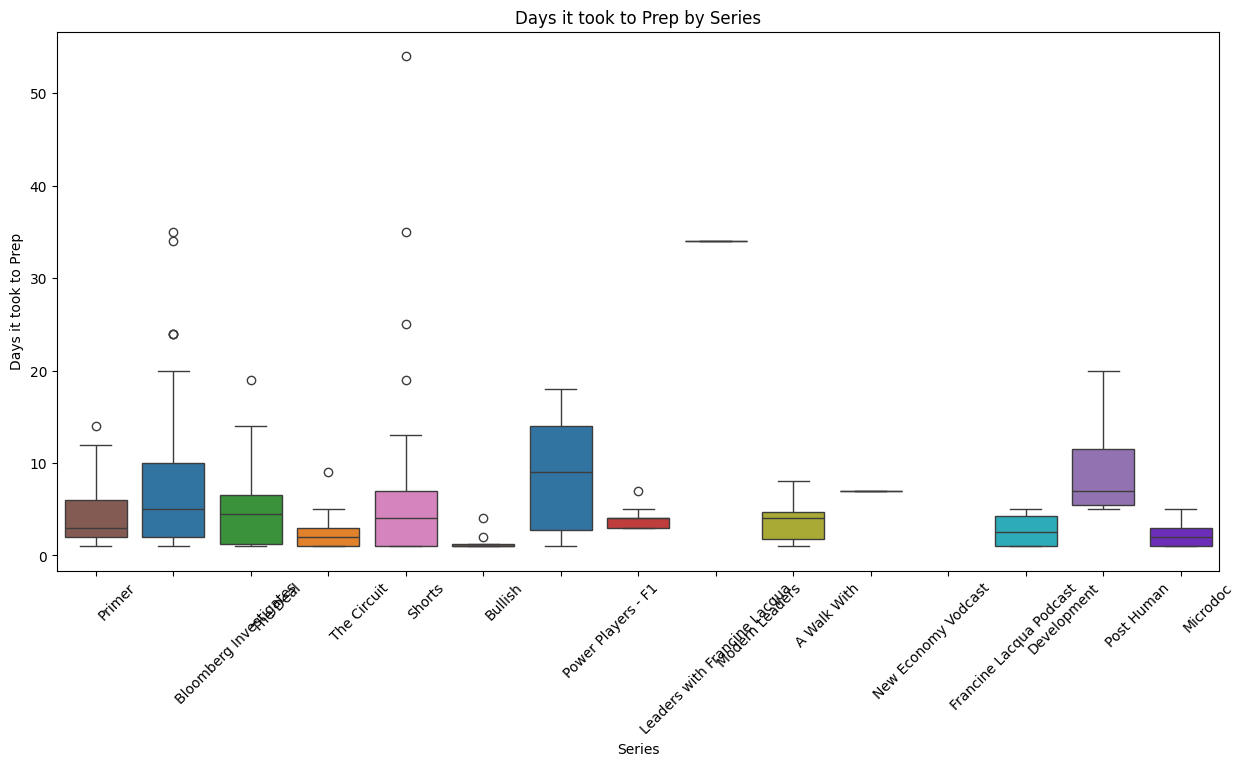

In [85]:
plot_boxplots(post_ops_prep_df, 'Series', 'Days it took to Prep', color_palette=show_color_palette)

In [88]:
post_ops_prep_df.groupby(['Series', 'Episode'])['Shoot ID'].describe()

count unique  \
Series      Episode                                    
A Walk With AWW_2511_buildabear             1      1   
            AWW_2601_bjarkeingels           1      1   
            AWW_2601_debbisoo               2      2   
            AWW_2601_grainnewafer           1      1   
            Libby Wadle                     0      0   
...                                       ...    ...   
The Deal    OG_TDL_042_TMcGrady             1      1   
            OG_TDL_043_JPegula              1      1   
            Power Players (Guest TBD)       0      0   
            Susie Wolff                     0      0   
            TDL_030_BelichickDalio          0      0   

                                                                                       top  \
Series      Episode                                                                          
A Walk With AWW_2511_buildabear            AWW_2511_buildabear_St Louis Missouri_16Oct2025   
            AWW_2601_bjarkeingels                         AWW_2601_bjarkeingels__13Feb2026   
            AWW_2601_debbisoo                                 AWW_2601_debbisoo__05Feb2026   
            AWW_2601_grainnewafer                         AWW_2601_grainnewafer__08May2026   
            Libby Wadle                                                                NaN   
...                                                                                    ...   
The Deal    OG_TDL_042_TMcGrady          OG_TDL_042_TMcGrady_Peerspace (address pending...   
            OG_TDL_043_JPegula           OG_TDL_043_JPegula_ARC Office (Miami, FL)_07Ap...   
            Power Players (Guest TBD)                                                  NaN   
            Susie Wolff                                                                NaN   
            TDL_030_BelichickDalio                                                     NaN   

                                        freq  
Series      Episode                           
A Walk With AWW_2511_buildabear            1  
            AWW_2601_bjarkeingels          1  
            AWW_2601_debbisoo              1  
            AWW_2601_grainnewafer          1  
            Libby Wadle                  NaN  
...                                      ...  
The Deal    OG_TDL_042_TMcGrady            1  
            OG_TDL_043_JPegula             1  
            Power Players (Guest TBD)    NaN  
            Susie Wolff                  NaN  
            TDL_030_BelichickDalio       NaN  

[195 rows x 4 columns]

In [89]:
# Group by Series and Episode, aggregate Shoot ID count and Days it took to Prep stats
summary_df = (
    post_ops_prep_df.groupby(["Series", "Episode"])
    .agg(
        num_shoot_days=("Shoot ID", "nunique"),
        mean_days_to_prep=("Days it took to Prep", "mean"),
        min_days_to_prep=("Days it took to Prep", "min"),
        max_days_to_prep=("Days it took to Prep", "max"),
        count_entries=("Days it took to Prep", "count"),
    )
    .reset_index()
)

summary_df.tail()


,Series,Episode,num_shoot_days,mean_days_to_prep,min_days_to_prep,max_days_to_prep,count_entries
190,The Deal,OG_TDL_042_TMcGrady,1,5.0,5,5,1
191,The Deal,OG_TDL_043_JPegula,1,5.0,5,5,1
192,The Deal,Power Players (Guest TBD),0,1.0,1,1,1
193,The Deal,Susie Wolff,0,4.0,4,4,1
194,The Deal,TDL_030_BelichickDalio,0,8.0,8,8,1


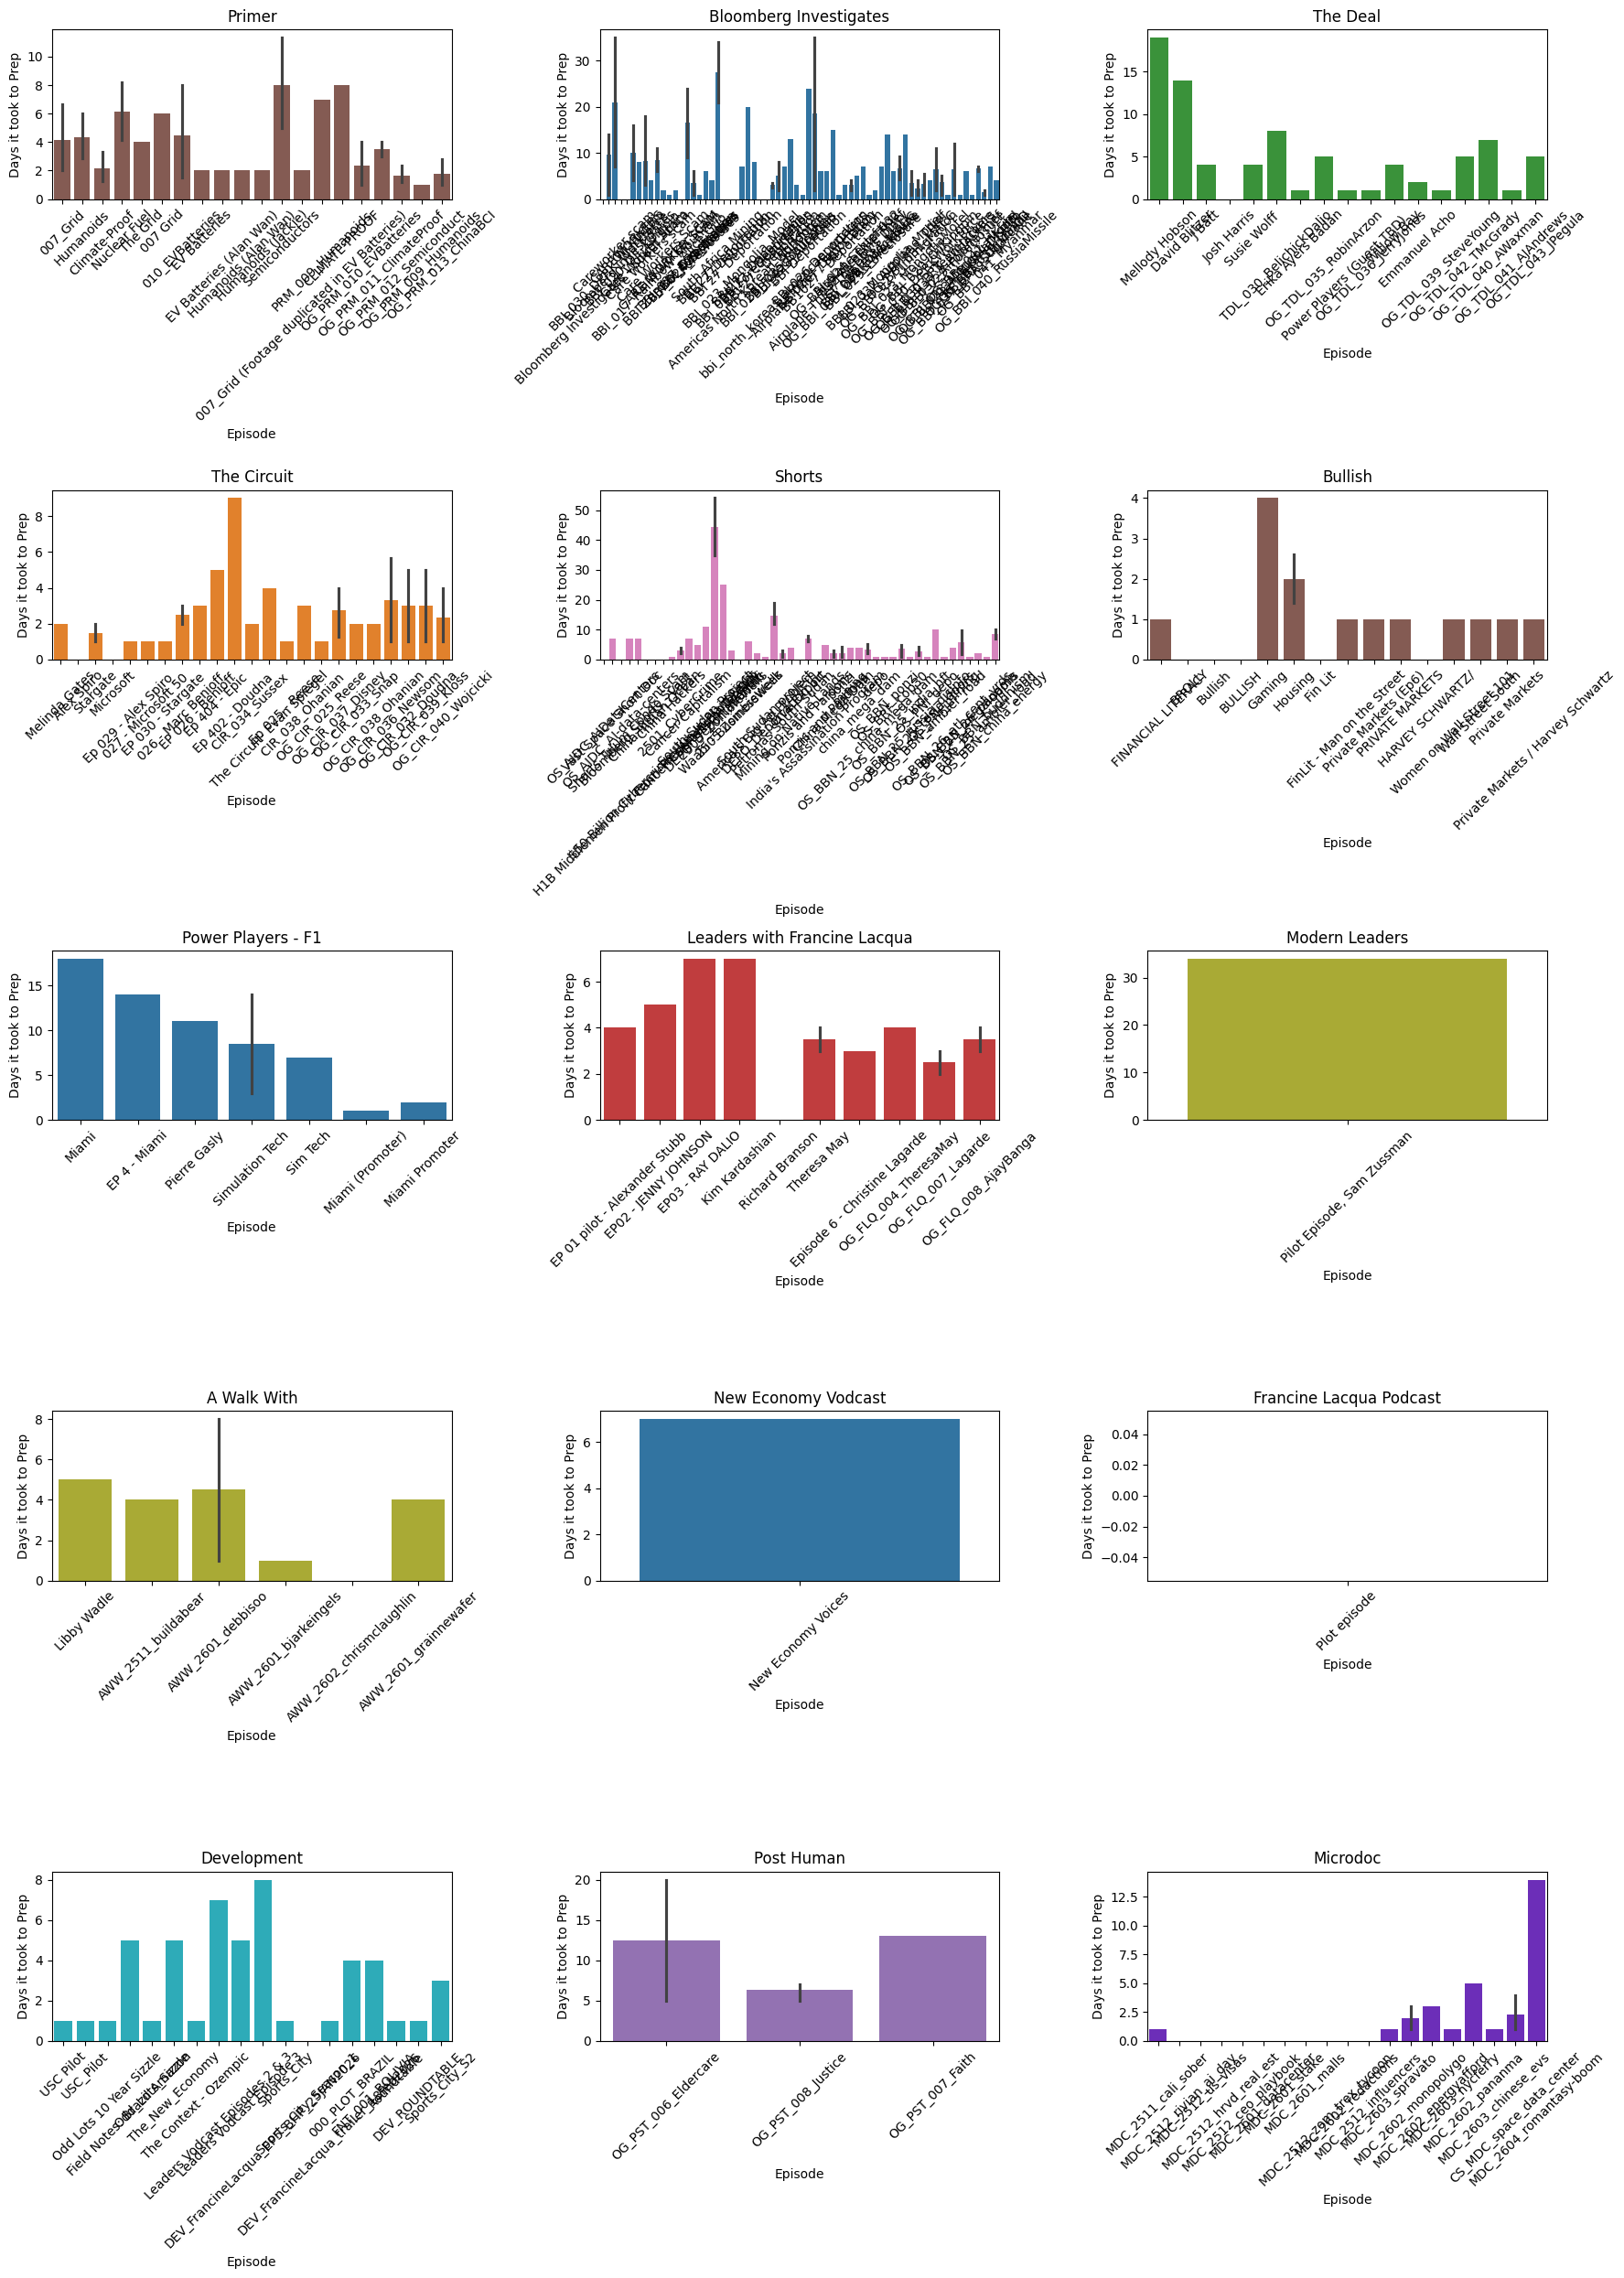

In [ ]:
# Subplots: Barplots of Days it took to Prep by Shoot, for each Episode, for each Series, with palette color by series, with x-axis labels rotated 45 degrees and aligned to the right
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")
series_list = post_ops_prep_df['Series'].dropna().unique()
num_series = len(series_list)
num_cols = 3
num_rows = (num_series + num_cols - 1) // num_cols
fig, axes = plt.subplots(num_rows, num_cols, figsize=(6*num_cols, 5*num_rows), squeeze=False)
for idx, series in enumerate(series_list):
    row, col = divmod(idx, num_cols)
    ax = axes[row][col]
    data = clean_df[clean_df['Series'] == series]
    color = show_color_palette.get(series, '#c7c7c7')
    sns.barplot(x='Episode', y='Days it took to Prep', data=data, color=color, ax=ax)
    ax.set_title(f'{series}')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Days it took to Prep')
    ax.tick_params(axis='x', rotation=45, labelrotation=45)
    if warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib"):
        ax.set_xticklabels(ax.get_xticklabels(), ha='right', rotation_mode='anchor')
    ax.grid(False)
# Hide any unused subplots
for idx in range(num_series, num_rows * num_cols):
    fig.delaxes(axes.flatten()[idx])
plt.tight_layout()
plt.show()

In [122]:
def wrap_labels(labels, width=5):
    return ["\n".join(textwrap.wrap(str(label), width=width)) for label in labels]

In [123]:
def plot_multi_shoot_subplots_by_series(df, color_palette, selected_series, num_cols=3):
    """
    Plotly subplots of Days it took to Prep by Shoot ID for episodes,
    for a single selected series.
    """
    # Filter for the selected series
    filtered_df = df[df["Series"] == selected_series]
    unique_episodes = filtered_df["Episode"].dropna().unique()
    num_eps = len(unique_episodes)
    num_rows = int((num_eps + num_cols - 1) // num_cols)
    total_subplots = num_rows * num_cols

    fig = make_subplots(
        rows=num_rows,
        cols=num_cols,
        subplot_titles=[
            ep if i < num_eps else ""
            for i, ep in enumerate(
                list(unique_episodes) + [""] * (total_subplots - num_eps)
            )
        ],
        horizontal_spacing=0.08,
        vertical_spacing=0.05,
    )

    color = color_palette.get(selected_series, "#c7c7c7")
    for ep_idx, episode in enumerate(unique_episodes):
        r, c = divmod(ep_idx, num_cols)
        ep_data = filtered_df[filtered_df["Episode"] == episode]
        wrapped_x = wrap_labels(ep_data["Shoot ID"])
        fig.add_trace(
            go.Bar(
                x=wrapped_x,
                y=ep_data["Days it took to Prep"],
                marker_color=color,
                name=str(episode),
                showlegend=False,
                hovertemplate="<b>%{x}</b><br>Days to Prep: %{y:.1f}<extra></extra>",
            ),
            row=r + 1,
            col=c + 1,
        )

    fig.update_xaxes(tickangle=45)
    fig.update_yaxes(title_text="Days it took to Prep")
    fig.update_layout(
        title=f"Days it took to Prep by Shoot ID — {selected_series}",
        height=400 * num_rows,
        width=1200,
    )
    fig.show()


In [124]:
plot_multi_shoot_subplots_by_series(
    post_ops_prep_df, show_color_palette, selected_series="The Circuit"
)


In [126]:
plot_multi_shoot_subplots_by_series(
    post_ops_prep_df, show_color_palette, selected_series="A Walk With")


In [127]:
def plot_multi_shoot_episode_subplots(df, show_color_palette, series_list=None, num_cols=2, wrap_width=15):
    """
    Plot subplots of Days it took to Prep and Number of Shoot Days by Shoot ID for each Episode (with multiple shoot days) for selected Series.
    
    Parameters:
        df (pd.DataFrame): Cleaned dataframe with columns 'Series', 'Episode', 'Shoot ID', 'Days it took to Prep', 'Total Number of Shoot Days'.
        show_color_palette (dict): Mapping of series names to colors.
        series_list (list, optional): List of series to include. If None, include all series.
        num_cols (int): Number of columns in subplot grid.
    """
    # Filter for selected series if provided
    if series_list is not None:
        df = df[df['Series'].isin(series_list)]
    # Find episodes with multiple shoot days
    multi_shoot_episodes = df.groupby(['Series', 'Episode'])['Shoot ID'].nunique().reset_index()
    # multi_shoot_episodes = multi_shoot_episodes[multi_shoot_episodes['Shoot ID'] > 1]
    episodes_to_plot = multi_shoot_episodes[['Series', 'Episode']].values.tolist()
    num_plots = len(episodes_to_plot)
    if num_plots == 0:
        print('No episodes with multiple shoot days found for the selected series.')
        return
    num_rows = (num_plots + num_cols - 1) // num_cols
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(6*num_cols, 5*num_rows), squeeze=False)
    for idx, (series, episode) in enumerate(episodes_to_plot):
        row, col = divmod(idx, num_cols)
        ax = axes[row][col]
        data = df[(df['Series'] == series) & (df['Episode'] == episode)]
        color = show_color_palette.get(series, '#c7c7c7')
        plot_df = data[['Shoot ID', 'Days it took to Prep', 'Total Number of Shoot Days']].set_index('Shoot ID')
        # Rename columns for clarity
        plot_df = plot_df.rename(columns={'Days it took to Prep': 'Prep Days', 'Total Number of Shoot Days': 'Shoot Days'})
        plot_df = plot_df[['Prep Days', 'Shoot Days']]
        # Plot vertical grouped bar plot (Shoot ID on x-axis)
        plot_df.plot(kind='bar', ax=ax, color=[color, '#888888'])
        ax.set_title(f'{series} - {episode}')
        ax.set_xlabel('Shoot ID')
        ax.set_ylabel('Days')
        ax.grid(False)
        ax.legend(['Prep Days', 'Shoot Days'])
    # Hide any unused subplots
    for idx in range(num_plots, num_rows * num_cols):
        fig.delaxes(axes.flatten()[idx])
    plt.tight_layout()
    plt.show()

In [128]:
multi_shoot_episodes = clean_df.groupby(['Series', 'Episode'])['Shoot ID'].nunique().reset_index()
multi_shoot_episodes.head()
episodes_to_plot = multi_shoot_episodes[['Series', 'Episode']].values.tolist()
episodes_to_plot[:10]
multi_shoot_episodes[multi_shoot_episodes['Shoot ID'] > 0]

,Series,Episode,Shoot ID
0,5 Questions - Dev,USC Pilot,1
1,A Walk With,AWW_2511_buildabear,1
2,A Walk With,AWW_2601_bjarkeingels,2
3,A Walk With,AWW_2601_debbisoo,2
4,A Walk With,AWW_2601_grainnewafer,1
...,...,...,...
260,The Deal,OG_TDL_040_AWaxman,1
261,The Deal,OG_TDL_041_AJAndrews,1
262,The Deal,OG_TDL_042_TMcGrady,1
263,The Deal,OG_TDL_043_JPegula,1


In [129]:


def plot_shoot_days_and_prep_days_subplots(df, show_color_palette, series_list=None, num_cols=2, wrap_width=15):
    """
    Plot subplots of Days it took to Prep and Number of Shoot Days by Shoot ID for each Episode for selected Series.
    
    Parameters:
        df (pd.DataFrame): Cleaned dataframe with columns 'Series', 'Episode', 'Shoot ID', 'Days it took to Prep'.
        show_color_palette (dict): Mapping of series names to colors.
        series_list (list, optional): List of series to include. If None, include all series.
        num_cols (int): Number of columns in subplot grid.
    """
    # Filter for selected series if provided
    if series_list is not None:
        df = df[df['Series'].isin(series_list)]
    
    # Find espisodes with at least 1 shoot day (i.e., multiple Shoot IDs per Series/Episode)
    multi_shoot_episodes = df.groupby(['Series', 'Episode'])['Shoot ID'].nunique().reset_index()
    multi_shoot_episodes = multi_shoot_episodes[multi_shoot_episodes['Shoot ID'] > 0]
    episodes_to_plot = multi_shoot_episodes[['Series', 'Episode']].values.tolist()

    num_plots = len(episodes_to_plot)
    if num_plots == 0:
        print('No episodes with multiple shoot days found for the selected series.')
        return
    num_rows = (num_plots + num_cols - 1) // num_cols
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(6*num_cols, 5*num_rows), squeeze=False)
    for idx, (series, episode) in enumerate(episodes_to_plot):
        row, col = divmod(idx, num_cols)
        ax = axes[row][col]
        data = df[(df['Series'] == series) & (df['Episode'] == episode)]
        color = show_color_palette.get(series, '#c7c7c7')
        plot_df = data[['Shoot ID', 'Days it took to Prep', 'Total Number of Shoot Days']].set_index('Shoot ID')
        # potentially rename columns to be more clear in the plot 
        plot_df = plot_df.rename(columns={'Days it took to Prep': 'Prep Days', 'Total Number of Shoot Days': 'Shoot Days'}) 
        plot_df = plot_df[['Prep Days', 'Shoot Days']]
        plot_df.plot(kind='bar', ax=ax, color=[color, '#888888'])
        ax.set_title(f'{series} - {episode}')
        xticklabels = [textwrap.fill(str(label.get_text()), wrap_width) for label in ax.get_xticklabels()]
        ax.set_xticklabels(xticklabels, ha='right', rotation=45, rotation_mode='anchor')
        ax.set_ylabel('Days')
        ax.grid(False)
        ax.legend(['Prep Days', 'Shoot Days'])      
        
    # Hide any unused subplots
    for idx in range(num_plots, num_rows * num_cols):
        fig.delaxes(axes.flatten()[idx])
    plt.tight_layout()
    plt.show()

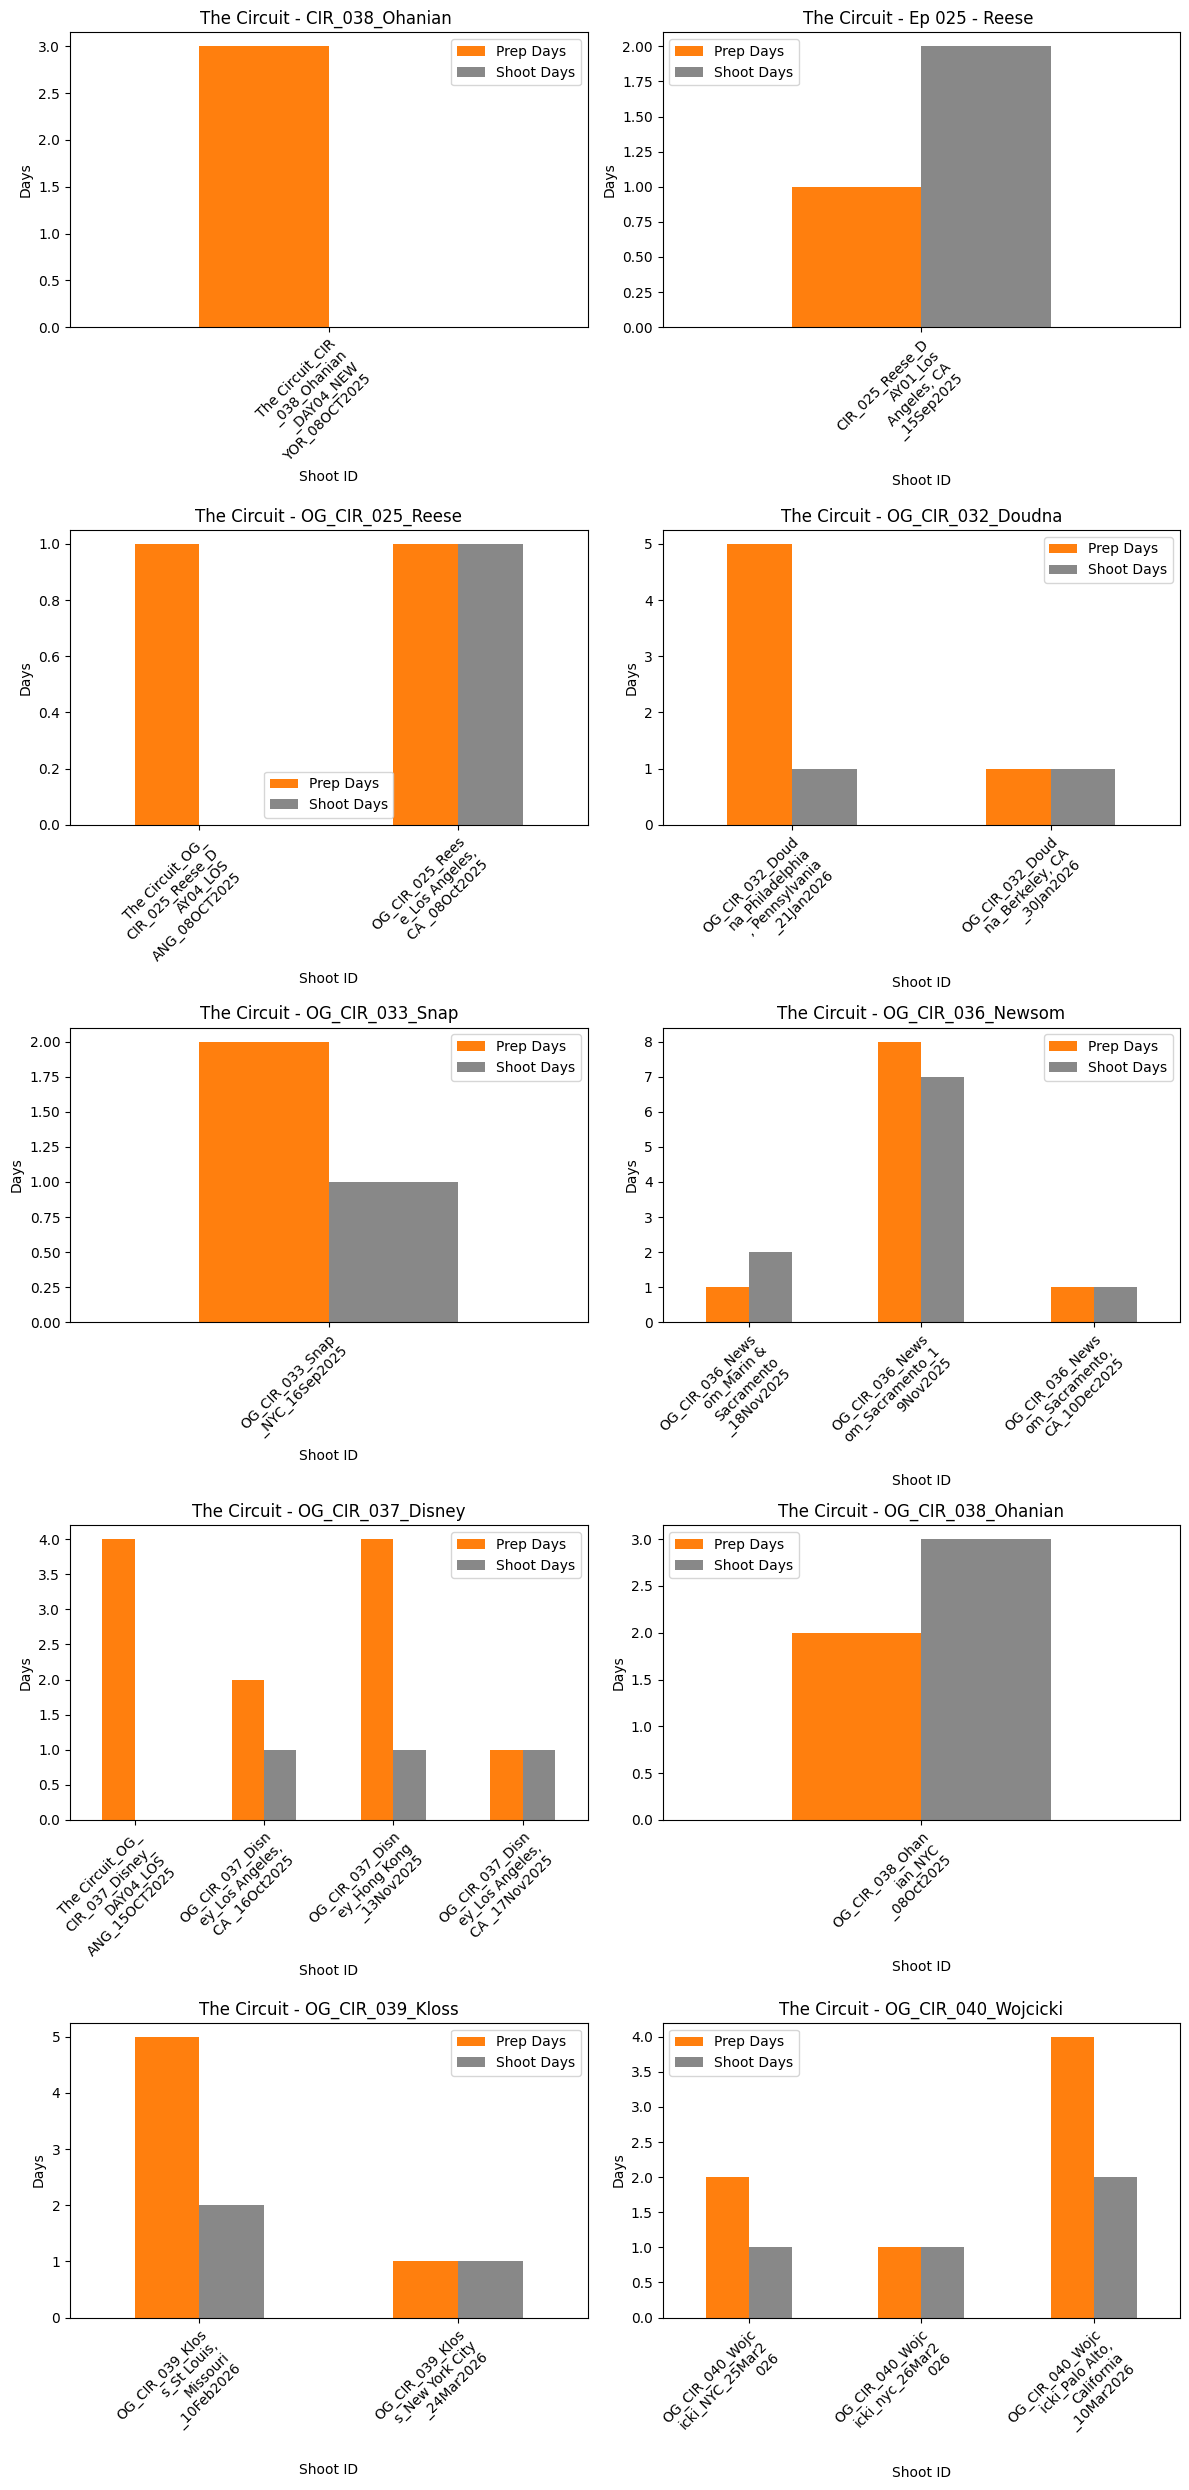

In [130]:
plot_shoot_days_and_prep_days_subplots(
    clean_df, 
    show_color_palette, 
    series_list=["The Circuit"], 
    num_cols=2, 
    wrap_width=15)

In [133]:
def plot_shoot_days_and_prep_days_subplots_plotly(
    df, show_color_palette, series_list=None, num_cols=2, wrap_width=15
):
    """
    Plotly subplots of Days it took to Prep and Number of Shoot Days by Shoot ID for each Episode for selected Series.
    """
    # Filter for selected series if provided
    if series_list is not None:
        df = df[df["Series"].isin(series_list)]

    # Find episodes with at least 1 shoot day
    multi_shoot_episodes = (
        df.groupby(["Series", "Episode"])["Shoot ID"].nunique().reset_index()
    )
    multi_shoot_episodes = multi_shoot_episodes[multi_shoot_episodes["Shoot ID"] > 0]
    episodes_to_plot = multi_shoot_episodes[["Series", "Episode"]].values.tolist()

    num_plots = len(episodes_to_plot)
    if num_plots == 0:
        print("No episodes with multiple shoot days found for the selected series.")
        return
    num_rows = (num_plots + num_cols - 1) // num_cols
    total_subplots = num_rows * num_cols

    fig = make_subplots(
        rows=num_rows,
        cols=num_cols,
        subplot_titles=[
            f"{series} - {episode}" if idx < num_plots else ""
            for idx, (series, episode) in enumerate(
                episodes_to_plot + [("", "")] * (total_subplots - num_plots)
            )
        ],
    )

    for idx, (series, episode) in enumerate(episodes_to_plot):
        row, col = divmod(idx, num_cols)
        data = df[(df["Series"] == series) & (df["Episode"] == episode)]
        color = show_color_palette.get(series, "#c7c7c7")
        plot_df = data[
            ["Shoot ID", "Days it took to Prep", "Total Number of Shoot Days"]
        ].set_index("Shoot ID")
        plot_df = plot_df.rename(
            columns={
                "Days it took to Prep": "Prep Days",
                "Total Number of Shoot Days": "Shoot Days",
            }
        )
        plot_df = plot_df[["Prep Days", "Shoot Days"]]
        x_labels = [textwrap.fill(str(label), wrap_width) for label in plot_df.index]
        wrapped_labels = [
            "<br>".join(textwrap.wrap(label, width=10)) for label in x_labels
        ]

        # Prep Days bar
        fig.add_trace(
            go.Bar(
                x=x_labels,
                y=plot_df["Prep Days"],
                name="Prep Days",
                marker_color=color,
                showlegend=(idx == 0),
            ),
            row=row + 1,
            col=col + 1,
        )
        # Shoot Days bar
        fig.add_trace(
            go.Bar(
                x=x_labels,
                y=plot_df["Shoot Days"],
                name="Shoot Days",
                marker_color="#888888",
                showlegend=(idx == 0),
            ),
            row=row + 1,
            col=col + 1,
        )

    fig.update_layout(
        height=400 * num_rows,
        width=600 * num_cols,
        barmode="group",
        title_text="Prep Days and Shoot Days by Shoot ID for Each Episode",
    )
    fig.update_xaxes(tickangle=45, tickvals=x_labels, ticktext=wrapped_labels)
    fig.update_yaxes(title_text="Days")
    fig.show()


In [134]:
plot_shoot_days_and_prep_days_subplots_plotly(
    post_ops_prep_df,
    show_color_palette,
    series_list=["The Circuit"],
    num_cols=2,
    wrap_width=15,
)

<Figure size 1000x600 with 0 Axes>

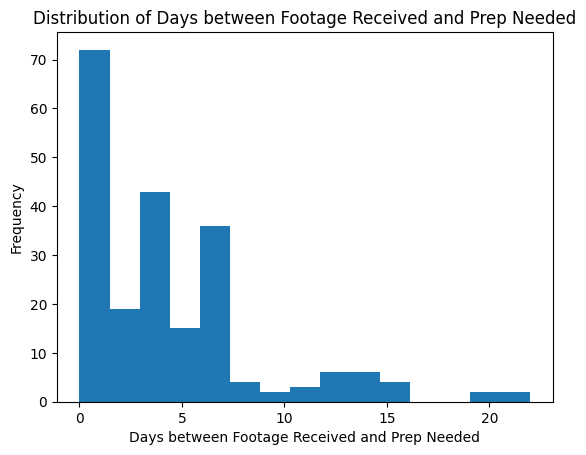

In [ ]:
plt.figure(figsize=(10, 6))
clean_df.hist(column='Days between Footage Rcvd and Prep Needed', bins=15, grid=False)
plt.title('Distribution of Days between Footage Received and Prep Needed')
plt.xlabel('Days between Footage Received and Prep Needed')
plt.ylabel('Frequency')
plt.show()

### Analysis of footage received on time, late, or early

In [ ]:
received_on_time = clean_df[clean_df['When Will Footage Be Received by Post'] == clean_df['Date Footage Actually Received']]
received_on_time.groupby('Series').size()

Series
A Walk With                      4
Bloomberg Investigates          31
Development                     13
Leaders with Francine Lacqua     3
Microdoc                        12
Not Found                       16
Post Human                       6
Primer                          12
Shorts                          20
The Circuit                      9
The Deal                         2
dtype: int64

In [ ]:
received_late = clean_df[clean_df['When Will Footage Be Received by Post'] < clean_df['Date Footage Actually Received']]
received_late.groupby('Series').size()

Series
A Walk With                1
Bloomberg Investigates    24
Development                3
Microdoc                   2
Not Found                  1
Primer                     3
Shorts                    13
The Circuit                6
The Deal                   3
dtype: int64

In [ ]:
received_early = clean_df[clean_df['When Will Footage Be Received by Post'] > clean_df['Date Footage Actually Received']]
received_early.groupby('Series').size()

Series
Bloomberg Investigates          2
Development                     1
Leaders with Francine Lacqua    2
Primer                          3
Shorts                          3
The Circuit                     1
dtype: int64

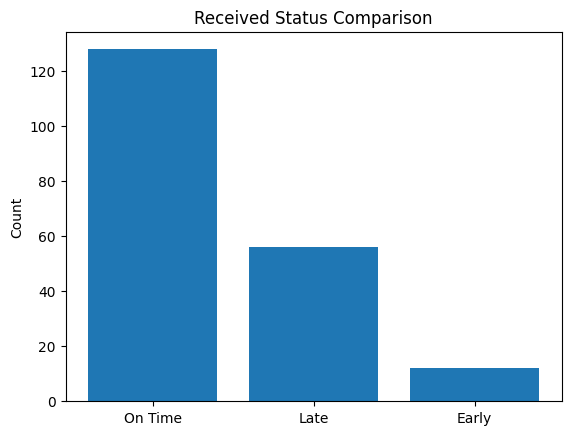

In [ ]:
labels = ["On Time", "Late", "Early"]
values = [received_on_time, received_late, received_early]

plt.bar(labels, [v.groupby('Series').size().sum() for v in values])
plt.ylabel("Count")
plt.title("Received Status Comparison")
plt.show()


In [ ]:
show_color_palette = {
    "A Walk With": "#bcbd22",
    "Bloomberg Investigates": "#1f77b4",
    "Development": "#17becf",   
    "Leaders with Francine Lacqua": "#d62728",
    "Post Human": "#9467bd",
    "Primer": "#8c564b",
    "Shorts": "#e377c2",
    "The Circuit": "#ff7f0e",
    "The Deal": "#2ca02c",
    "Weekly & Cross Platform Videos": "#7f7f7f",
    "Not Found": "#c7c7c7"}

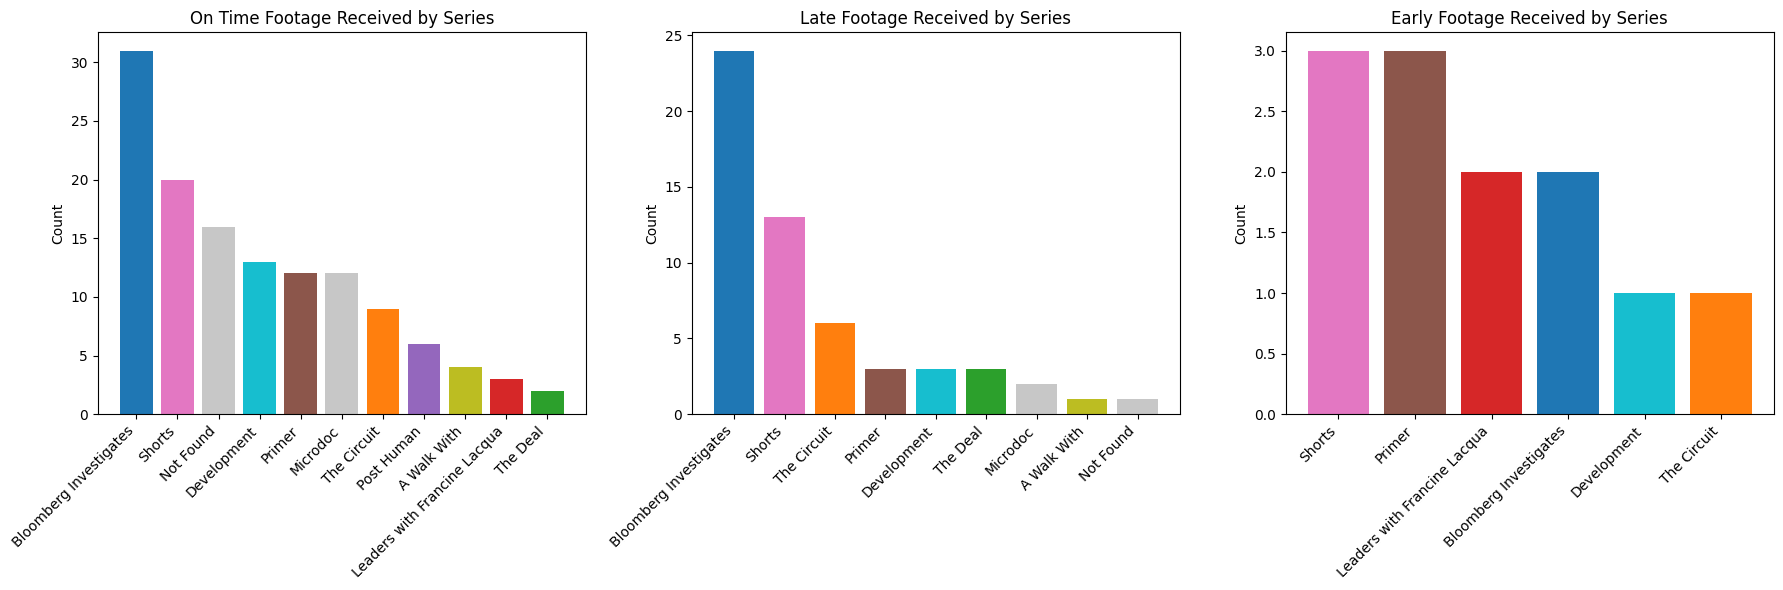

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
dataframes = [received_on_time, received_late, received_early]
labels = ["On Time", "Late", "Early"]

warnings.filterwarnings("ignore", category=UserWarning)

for ax, df, label in zip(axes, dataframes, labels):
    counts = df.groupby('Series').size().sort_values(ascending=False)
    ax.bar(counts.index, 
        counts.values, 
        
        label=label, 
        color=[show_color_palette.get(series, "#c7c7c7") for series in counts.index])
    ax.set_ylabel("Count")
    ax.set_title(f"{label} Footage Received by Series")
    ax.set_xticklabels(counts.index, rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [ ]:
import seaborn as sns

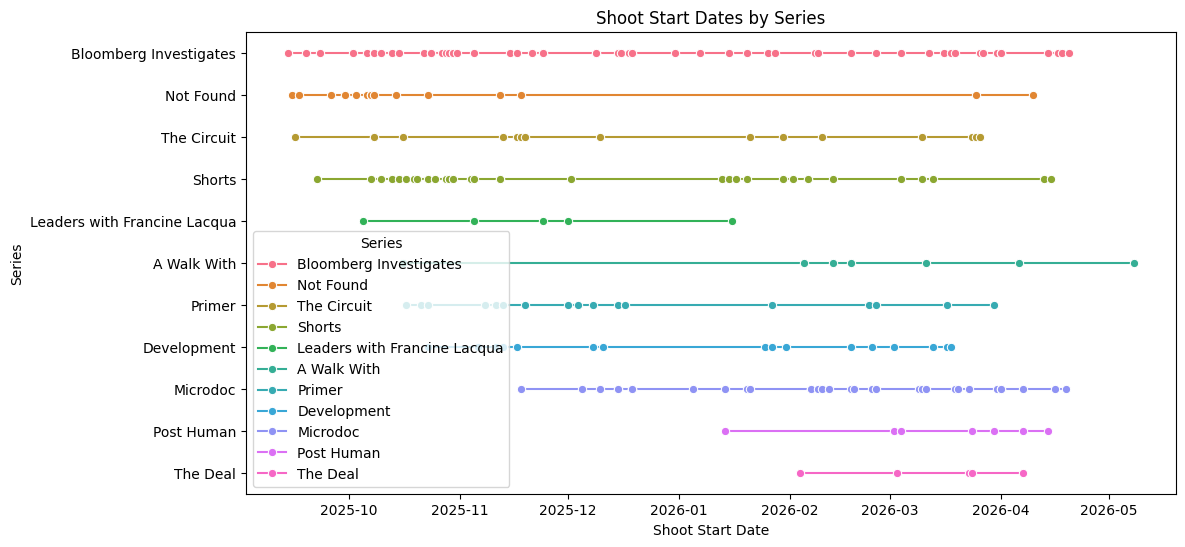

In [ ]:
df = clean_df.sort_values("Shoot Start Date")

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df, x="Shoot Start Date", y="Series", hue="Series", estimator=None, marker="o"
)
plt.title("Shoot Start Dates by Series")
plt.xlabel("Shoot Start Date")
plt.ylabel("Series")
plt.legend(title="Series")
plt.show()


In [ ]:
avg_prep_time_by_series = clean_df.groupby("Series")["Days it took to Prep"].mean().sort_values(ascending=False)
print(avg_prep_time_by_series)

Series
Post Human                           6.0
Bloomberg Investigates          3.972222
A Walk With                     3.333333
The Deal                             3.0
Leaders with Francine Lacqua         3.0
Shorts                               3.0
Development                          2.5
The Circuit                     1.909091
Microdoc                        1.888889
Primer                          1.636364
Not Found                       1.166667
Name: Days it took to Prep, dtype: Float64


In [ ]:
clean_df.head()

,Status,Series,Episode,Shoot Location,Shoot Dates,Who is Prepping,Days between Footage Rcvd and Prep Needed,Prep Priority,When Will Footage Be Received by Post,Date Footage Actually Received,When Is Prep Needed By,Date Prep Completed,Days it took to Prep,Shoot Start Date,Total Number of Shoot Days,Shoot End Date,AE Requests,"If Translations Are Needed, What Language",Is this currently in edit?,Dropped / Shipped / Uploaded,Where is footage being delivered to?,How is it being delivered?,How is Media Being Returned,Showrunner / Lead Producer,Equipment,Shoot ID,Timestamp,Vertical,Cross Platform Videos,Time Between Submission and Shoot Start
0,Complete,Bloomberg Investigates,OG_BBI_027_Immigration,"Portland, OR",14-Sep-2025,Nancy,15,#REF!,2025-10-14,2025-10-20,2025-10-29,2025-10-23,3,2025-09-14,1,2025-09-14,"Stringouts, Transcripts",NaN,No,Uploaded to Frame.io,NaN,NaN,Remote (Frame.io Upload),NaN,NaN,"OG_BBI_027_Immigration_Portland, OR_14Sep2025",2025-10-07 14:16:54,Long Form,NaN,-23
1,Complete,Not Found,ponzi,NYC,15-Sep-2025,NaN,1,#REF!,2025-09-17,2025-09-17,2025-09-18,2025-09-19,2,2025-09-15,1,2025-09-15,"Stringouts, Transcripts",NaN,No,Dropped at NYC Office - 731 Lexington Ave,NYC Office - 731 Lexington Ave,Drives Dropped off at Office,Drives or Cards,James Rattee,Bloomberg NYC Equipment,ponzi_NYC_15Sep2025,2025-09-16 16:03:14,Evergreen Shorts,NaN,-1
2,Complete,The Circuit,OG_CIR_033_Snap,NYC,16-Sep-2025,NaN,2,#REF!,2025-09-17,2025-09-17,2025-09-19,2025-09-19,<NA>,2025-09-16,1,2025-09-16,"Stringouts, Transcripts",NaN,Yes,Dropped at NYC Office - 731 Lexington Ave,NYC Office - 731 Lexington Ave,Drives Dropped off at Office,Drives or Cards,Lauren Ellis,Bloomberg NYC Equipment,OG_CIR_033_Snap_NYC_16Sep2025,2025-09-16 16:24:18,Long Form,NaN,0
3,Complete,Not Found,ponzi,NY,17-Sep-2025,NaN,5,#REF!,2025-09-17,2025-09-17,2025-09-22,2025-09-22,<NA>,2025-09-17,1,2025-09-17,"Stringouts, Transcripts",NaN,No,Dropped at NYC Office - 731 Lexington Ave,NYC Office - 731 Lexington Ave,Drives Dropped off at Office,Drives or Cards,James Rattee,Bloomberg NYC Equipment,ponzi_NY_17Sep2025,2025-09-17 11:45:43,Evergreen Shorts,NaN,0
4,Complete,Bloomberg Investigates,OG_BBI_027_Immigration,"Portland, OR",19-Sep-2025,Nancy,15,#REF!,2025-10-14,2025-10-20,2025-10-29,2025-10-23,3,2025-09-19,1,2025-09-19,"Stringouts, Transcripts",NaN,No,Uploaded to Frame.io,NaN,NaN,Remote (Frame.io Upload),NaN,NaN,"OG_BBI_027_Immigration_Portland, OR_19Sep2025",2025-10-07 14:18:16,Long Form,NaN,-18


In [ ]:
bloomberg_investigates_df = clean_df[clean_df["Series"] == "Bloomberg Investigates"]
bloomberg_investigates_df.head()

,Status,Series,Episode,Shoot Location,Shoot Dates,Who is Prepping,Days between Footage Rcvd and Prep Needed,Prep Priority,When Will Footage Be Received by Post,Date Footage Actually Received,When Is Prep Needed By,Date Prep Completed,Days it took to Prep,Shoot Start Date,Total Number of Shoot Days,Shoot End Date,AE Requests,"If Translations Are Needed, What Language",Is this currently in edit?,Dropped / Shipped / Uploaded,Where is footage being delivered to?,How is it being delivered?,How is Media Being Returned,Showrunner / Lead Producer,Equipment,Shoot ID,Timestamp,Vertical,Cross Platform Videos,Time Between Submission and Shoot Start
0,Complete,Bloomberg Investigates,OG_BBI_027_Immigration,"Portland, OR",14-Sep-2025,Nancy,15,#REF!,2025-10-14,2025-10-20,2025-10-29,2025-10-23,3,2025-09-14,1,2025-09-14,"Stringouts, Transcripts",NaN,No,Uploaded to Frame.io,NaN,NaN,Remote (Frame.io Upload),NaN,NaN,"OG_BBI_027_Immigration_Portland, OR_14Sep2025",2025-10-07 14:16:54,Long Form,NaN,-23
4,Complete,Bloomberg Investigates,OG_BBI_027_Immigration,"Portland, OR",19-Sep-2025,Nancy,15,#REF!,2025-10-14,2025-10-20,2025-10-29,2025-10-23,3,2025-09-19,1,2025-09-19,"Stringouts, Transcripts",NaN,No,Uploaded to Frame.io,NaN,NaN,Remote (Frame.io Upload),NaN,NaN,"OG_BBI_027_Immigration_Portland, OR_19Sep2025",2025-10-07 14:18:16,Long Form,NaN,-18
6,Complete,Bloomberg Investigates,OG_BBI_027_Immigration,"Portland, OR",23-Sep-2025,Nancy,15,#REF!,2025-10-14,2025-10-20,2025-10-29,2025-10-23,3,2025-09-23,1,2025-09-23,"Stringouts, Transcripts",NaN,No,Uploaded to Frame.io,NaN,NaN,Remote (Frame.io Upload),NaN,NaN,"OG_BBI_027_Immigration_Portland, OR_23Sep2025",2025-10-07 14:19:34,Long Form,NaN,-14
10,Complete,Bloomberg Investigates,OG_BBI_031_MACC,"Kuala Lumpur & Putrajaya, Malaysia",02-Oct-2025,Nancy,7,#REF!,2025-10-14,2025-10-14,2025-10-21,2025-10-20,6,2025-10-02,1,2025-10-02,"Stringouts, Transcripts",NaN,No,Uploaded to Frame.io,NaN,NaN,Remote (Frame.io Upload),NaN,NaN,NaN,2025-09-24 22:45:27,NaN,NaN,8
14,Complete,Bloomberg Investigates,OG_BBI_027_Immigration,"Portland, OR",06-Oct-2025,Will,15,#REF!,2025-10-14,2025-10-14,2025-10-29,2025-10-29,<NA>,2025-10-06,1,2025-10-06,"Stringouts, Transcripts",NaN,No,Uploaded to Frame.io,NaN,NaN,Remote (Frame.io Upload),NaN,NaN,"OG_BBI_027_Immigration_Portland, OR_06Oct2025",2025-10-07 14:20:33,Long Form,NaN,-1


In [ ]:
bloomberg_investigates_df.groupby("Episode")["Days it took to Prep"].mean().sort_values(ascending=False)

Episode
OG_BBI_038_LundinOil             6.0
OG_BBI_037_BRA_Sugarcane         6.0
OG_BBI_027_Immigration      5.315789
OG_BBI_032_AirplaneThief    3.666667
OG_BBI_031_MACC                  3.5
OG_BBI_033_TeenHackers           2.0
OG_BBI_039_USAID                 1.5
OG_BBI_023_MongoliaModel         1.0
OG_BBI_020_OilKingpin            1.0
OG_BBI_030_DPRKWorkforce         1.0
OG_BBI_029_Foreclosure           1.0
OG_BBI_034_RussiaDisinfo         1.0
OG_BBI_042_HKFire                1.0
OG_BBI_040_RussiaMissile        <NA>
OG_BBI_041_Myanmar              <NA>
Name: Days it took to Prep, dtype: Float64

Text(0.5, 1.0, 'Average Days it took to Prep by Episode for Bloomberg Investigates')

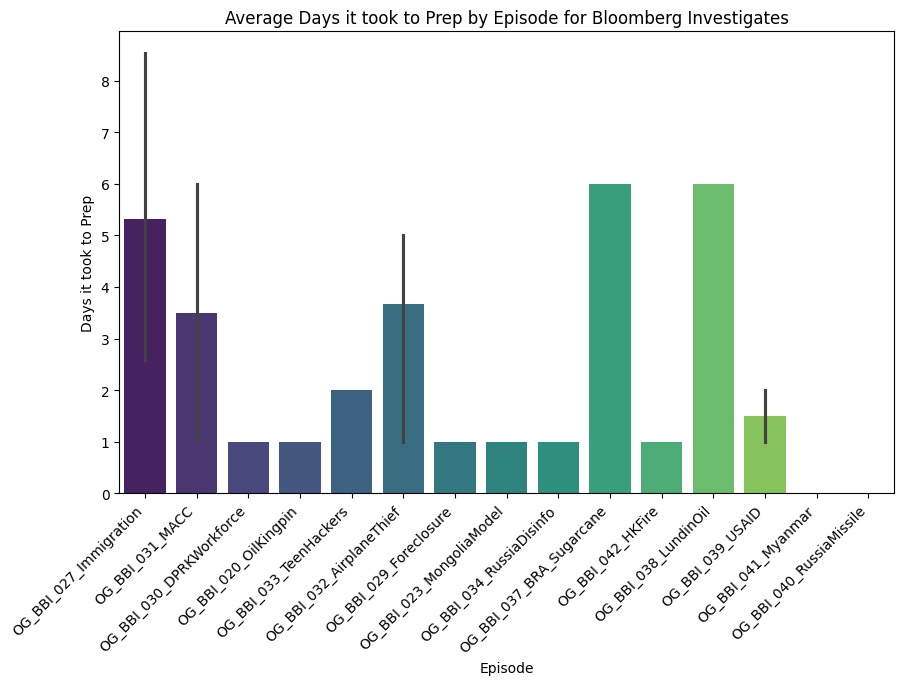

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=bloomberg_investigates_df, 
            x="Episode", 
            y="Days it took to Prep",
            hue = "Episode",
            estimator="mean",
            palette="viridis",
            legend=False)
plt.xlabel("Episode")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Days it took to Prep")
plt.title("Average Days it took to Prep by Episode for Bloomberg Investigates")

In [ ]:
clean_df['week'] = clean_df['Shoot Start Date'].dt.to_period('W').apply(lambda r: r.start_time)

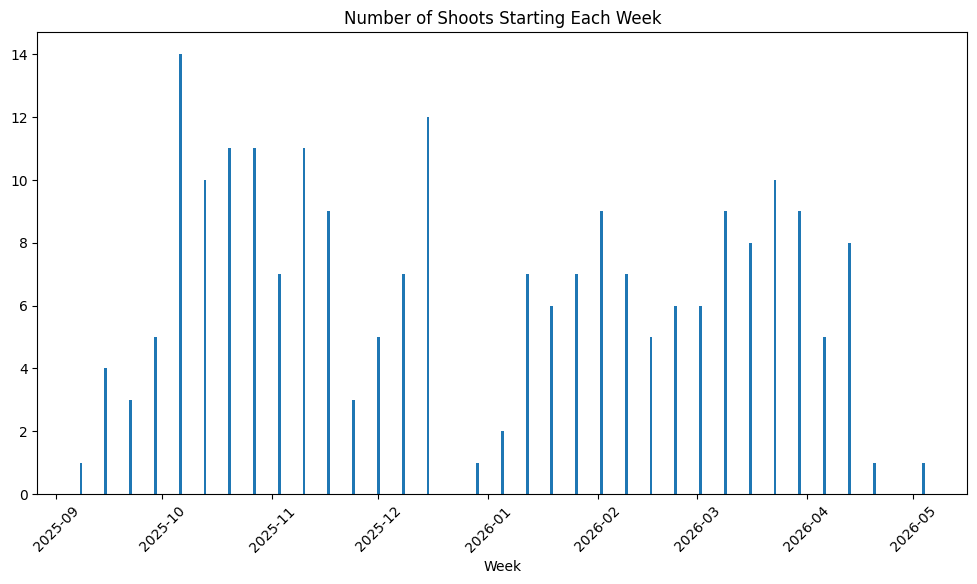

In [ ]:
plt.figure(figsize=(12, 6))
plt.bar(clean_df.groupby('week').size().index, clean_df.groupby('week').size().values)
plt.xlabel("Week")  
plt.xticks(rotation=45)
plt.title("Number of Shoots Starting Each Week")
plt.show()

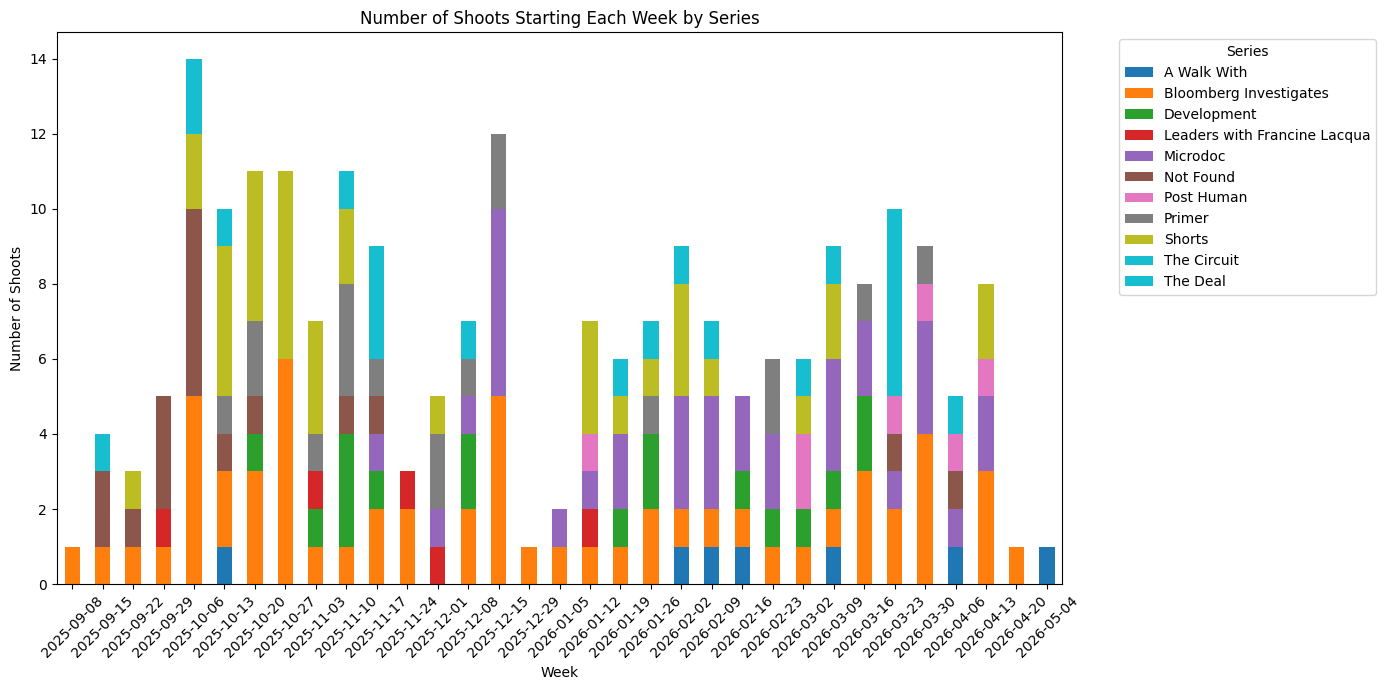

In [ ]:
# Group by both 'week' and 'Series', then unstack to get a table suitable for plotting
weekly_series_counts = (
    clean_df.groupby(["week", "Series"]).size().unstack(fill_value=0)
)

plt.figure(figsize=(14, 7))
weekly_series_counts.plot(kind="bar", stacked=True, colormap="tab10", ax=plt.gca())
plt.xlabel("Week")
plt.ylabel("Number of Shoots")
plt.title("Number of Shoots Starting Each Week by Series")
plt.xticks(
    ticks=range(len(weekly_series_counts.index)),
    labels=[d.strftime("%Y-%m-%d") for d in weekly_series_counts.index],
    rotation=45,
)
plt.legend(title="Series", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [ ]:
#What are the "not Found" series? Are they mislabeled entries that should be categorized under one of the existing series, or do they represent a distinct category that needs to be analyzed separately?
not_found_series = clean_df[clean_df['Series'] == 'Not Found']
print(not_found_series)

             Status     Series                   Episode  \
1          Complete  Not Found                     ponzi   
3          Complete  Not Found                     ponzi   
7          Complete  Not Found                    mining   
8          Complete  Not Found  OG_BBI_023_MongoliaMotel   
9          Complete  Not Found                     ponzi   
11         Complete  Not Found              Plot episode   
13         Complete  Not Found             Emmanuel Acho   
15         Complete  Not Found     OS_BBN_china_mega_dam   
17         Complete  Not Found      BBI_029_Foreclosure    
18         Complete  Not Found                      depo   
23         Complete  Not Found  OG_BBI_030_PRK_Workforce   
29   Done by Editor  Not Found              OS_BRF_cop30   
42         Complete  Not Found                 USC Pilot   
73         Complete  Not Found        OS_BBN_ambler_road   
82         Complete  Not Found    BBI_030_DPRK_Workforce   
162  Done by Editor  Not Found          

In [ ]:
not_found_series.head()

,Status,Series,Episode,Shoot Location,Shoot Dates,Who is Prepping,Days between Footage Rcvd and Prep Needed,Prep Priority,When Will Footage Be Received by Post,Date Footage Actually Received,When Is Prep Needed By,Date Prep Completed,Days it took to Prep,Shoot Start Date,Total Number of Shoot Days,Shoot End Date,AE Requests,"If Translations Are Needed, What Language",Is this currently in edit?,Dropped / Shipped / Uploaded,Where is footage being delivered to?,How is it being delivered?,How is Media Being Returned,Showrunner / Lead Producer,Equipment,Shoot ID,Timestamp,Vertical,Cross Platform Videos,Time Between Submission and Shoot Start,week
1,Complete,Not Found,ponzi,NYC,15-Sep-2025,NaN,1,#REF!,2025-09-17,2025-09-17,2025-09-18,2025-09-19,2,2025-09-15,1,2025-09-15,"Stringouts, Transcripts",NaN,No,Dropped at NYC Office - 731 Lexington Ave,NYC Office - 731 Lexington Ave,Drives Dropped off at Office,Drives or Cards,James Rattee,Bloomberg NYC Equipment,ponzi_NYC_15Sep2025,2025-09-16 16:03:14,Evergreen Shorts,NaN,-1,2025-09-15
3,Complete,Not Found,ponzi,NY,17-Sep-2025,NaN,5,#REF!,2025-09-17,2025-09-17,2025-09-22,2025-09-22,<NA>,2025-09-17,1,2025-09-17,"Stringouts, Transcripts",NaN,No,Dropped at NYC Office - 731 Lexington Ave,NYC Office - 731 Lexington Ave,Drives Dropped off at Office,Drives or Cards,James Rattee,Bloomberg NYC Equipment,ponzi_NY_17Sep2025,2025-09-17 11:45:43,Evergreen Shorts,NaN,0,2025-09-15
7,Complete,Not Found,mining,Washington DC Bloomberg Office,26-Sep-2025,NaN,4,#REF!,2025-09-29,2025-09-29,2025-10-03,2025-10-03,<NA>,2025-09-26,1,2025-09-26,"Stringouts, Transcripts",NaN,No,Dropped at NYC Office - 731 Lexington Ave,NYC Office - 731 Lexington Ave,Drives Dropped off at Office,Drives or Cards,Henry Baker,Bloomberg NYC Equipment,mining_Washington DC Bloomberg Office_26Sep2025,2025-09-24 10:20:46,Evergreen Shorts,NaN,2,2025-09-22
8,Complete,Not Found,OG_BBI_023_MongoliaMotel,"Kuala Lumpur & Putrajaya, Malaysia",30-Sep-2025,Juniper,14,#REF!,2025-10-15,2025-10-15,2025-10-29,2025-10-29,<NA>,2025-09-30,1,2025-09-30,"Stringouts, Transcripts",NaN,No,Uploaded to Frame.io,NaN,NaN,Remote (Frame.io Upload),NaN,NaN,OG_BBI_023_MongoliaMotel_Kuala Lumpur & Putraj...,2025-09-24 22:48:21,Long Form,NaN,6,2025-09-29
9,Complete,Not Found,ponzi,Washington DC,30-Sep-2025,NaN,1,#REF!,2025-10-01,2025-10-01,2025-10-02,2025-10-02,<NA>,2025-09-30,1,2025-09-30,Stringouts,NaN,Yes,Dropped at NYC Office - 731 Lexington Ave,NYC Office - 731 Lexington Ave,Drives Dropped off at Office,Drives or Cards,James Rattee,External Renting Equipment,ponzi_Washington DC_30Sep2025,2025-09-26 10:19:24,Evergreen Shorts,NaN,4,2025-09-29


In [ ]:
not_found_series.groupby('Episode').size()

Episode
BBI_029_Foreclosure         1
BBI_030_DPRK_Workforce      1
Emmanuel Acho               1
OG_BBI_023_MongoliaMotel    1
OG_BBI_030_PRK_Workforce    1
OS_BBN_ambler_road          1
OS_BBN_china_mega_dam       1
OS_BRF_cop30                1
Plot episode                1
Sports_City_S2              1
USC Pilot                   1
depo                        1
mining                      1
ponzi                       3
dtype: int64

In [ ]:
for series in clean_df['Series'].unique():
    if series == 'Not Found':
        if clean_df["Episode"].str.contains("BBI", na=False).any():
            clean_df.loc[clean_df["Episode"].str.contains("BBI", na=False), "Series"] = "Bloomberg Investigates"


In [ ]:
clean_df.head()

,Status,Series,Episode,Shoot Location,Shoot Dates,Who is Prepping,Days between Footage Rcvd and Prep Needed,Prep Priority,When Will Footage Be Received by Post,Date Footage Actually Received,When Is Prep Needed By,Date Prep Completed,Days it took to Prep,Shoot Start Date,Total Number of Shoot Days,Shoot End Date,AE Requests,"If Translations Are Needed, What Language",Is this currently in edit?,Dropped / Shipped / Uploaded,Where is footage being delivered to?,How is it being delivered?,How is Media Being Returned,Showrunner / Lead Producer,Equipment,Shoot ID,Timestamp,Vertical,Cross Platform Videos,Time Between Submission and Shoot Start,week
0,Complete,Bloomberg Investigates,OG_BBI_027_Immigration,"Portland, OR",14-Sep-2025,Nancy,15,#REF!,2025-10-14,2025-10-20,2025-10-29,2025-10-23,3,2025-09-14,1,2025-09-14,"Stringouts, Transcripts",NaN,No,Uploaded to Frame.io,NaN,NaN,Remote (Frame.io Upload),NaN,NaN,"OG_BBI_027_Immigration_Portland, OR_14Sep2025",2025-10-07 14:16:54,Long Form,NaN,-23,2025-09-08
1,Complete,Not Found,ponzi,NYC,15-Sep-2025,NaN,1,#REF!,2025-09-17,2025-09-17,2025-09-18,2025-09-19,2,2025-09-15,1,2025-09-15,"Stringouts, Transcripts",NaN,No,Dropped at NYC Office - 731 Lexington Ave,NYC Office - 731 Lexington Ave,Drives Dropped off at Office,Drives or Cards,James Rattee,Bloomberg NYC Equipment,ponzi_NYC_15Sep2025,2025-09-16 16:03:14,Evergreen Shorts,NaN,-1,2025-09-15
2,Complete,The Circuit,OG_CIR_033_Snap,NYC,16-Sep-2025,NaN,2,#REF!,2025-09-17,2025-09-17,2025-09-19,2025-09-19,<NA>,2025-09-16,1,2025-09-16,"Stringouts, Transcripts",NaN,Yes,Dropped at NYC Office - 731 Lexington Ave,NYC Office - 731 Lexington Ave,Drives Dropped off at Office,Drives or Cards,Lauren Ellis,Bloomberg NYC Equipment,OG_CIR_033_Snap_NYC_16Sep2025,2025-09-16 16:24:18,Long Form,NaN,0,2025-09-15
3,Complete,Not Found,ponzi,NY,17-Sep-2025,NaN,5,#REF!,2025-09-17,2025-09-17,2025-09-22,2025-09-22,<NA>,2025-09-17,1,2025-09-17,"Stringouts, Transcripts",NaN,No,Dropped at NYC Office - 731 Lexington Ave,NYC Office - 731 Lexington Ave,Drives Dropped off at Office,Drives or Cards,James Rattee,Bloomberg NYC Equipment,ponzi_NY_17Sep2025,2025-09-17 11:45:43,Evergreen Shorts,NaN,0,2025-09-15
4,Complete,Bloomberg Investigates,OG_BBI_027_Immigration,"Portland, OR",19-Sep-2025,Nancy,15,#REF!,2025-10-14,2025-10-20,2025-10-29,2025-10-23,3,2025-09-19,1,2025-09-19,"Stringouts, Transcripts",NaN,No,Uploaded to Frame.io,NaN,NaN,Remote (Frame.io Upload),NaN,NaN,"OG_BBI_027_Immigration_Portland, OR_19Sep2025",2025-10-07 14:18:16,Long Form,NaN,-18,2025-09-15


In [ ]:
not_found_series = clean_df[clean_df["Series"] == "Not Found"]


In [ ]:
not_found_series.groupby('Episode').size()

Episode
Emmanuel Acho            1
OS_BBN_ambler_road       1
OS_BBN_china_mega_dam    1
OS_BRF_cop30             1
Plot episode             1
Sports_City_S2           1
USC Pilot                1
depo                     1
mining                   1
ponzi                    3
dtype: int64

In [ ]:
clean_df.groupby("Series").size()

Series
A Walk With                      7
Bloomberg Investigates          62
Development                     17
Leaders with Francine Lacqua     5
Microdoc                        34
Not Found                       13
Post Human                       7
Primer                          18
Shorts                          36
The Circuit                     16
The Deal                         5
dtype: int64

In [ ]:
not_found_series.describe()

,Days between Footage Rcvd and Prep Needed,When Will Footage Be Received by Post,Date Footage Actually Received,When Is Prep Needed By,Date Prep Completed,Days it took to Prep,Shoot Start Date,Total Number of Shoot Days,Shoot End Date,Timestamp,Time Between Submission and Shoot Start,week
count,12.0,13,13,12,12,5.0,13,13.0,13,13,13.0,13
mean,2.75,2025-11-04 09:13:50.769230848,2025-11-04 11:04:36.923076864,2025-11-09 22:00:00,2025-11-09 20:00:00,1.2,2025-11-02 18:27:41.538461440,1.461538,2025-11-03 05:32:18.461538560,2025-10-31 00:30:56.846153984,3.307692,2025-10-31 20:18:27.692307712
min,0.0,2025-09-17 00:00:00,2025-09-17 00:00:00,2025-09-18 00:00:00,2025-09-19 00:00:00,1.0,2025-09-15 00:00:00,1.0,2025-09-15 00:00:00,2025-09-16 16:03:14,-1.0,2025-09-15 00:00:00
25%,0.75,2025-10-01 00:00:00,2025-10-01 00:00:00,2025-10-02 18:00:00,2025-10-02 18:00:00,1.0,2025-09-30 00:00:00,1.0,2025-09-30 00:00:00,2025-09-26 10:19:24,2.0,2025-09-29 00:00:00
50%,2.5,2025-10-07 00:00:00,2025-10-07 00:00:00,2025-10-11 00:00:00,2025-10-11 00:00:00,1.0,2025-10-07 00:00:00,1.0,2025-10-07 00:00:00,2025-10-01 09:03:26,2.0,2025-10-06 00:00:00
75%,4.0,2025-10-27 00:00:00,2025-10-27 00:00:00,2025-11-07 00:00:00,2025-11-05 12:00:00,1.0,2025-10-23 00:00:00,1.0,2025-10-23 00:00:00,2025-10-16 16:15:33,4.0,2025-10-20 00:00:00
max,10.0,2026-04-10 00:00:00,2026-04-10 00:00:00,2026-04-13 00:00:00,2026-04-13 00:00:00,2.0,2026-04-10 00:00:00,7.0,2026-04-10 00:00:00,2026-04-08 12:54:00,10.0,2026-04-06 00:00:00
std,2.864358,NaN,NaN,NaN,NaN,0.447214,NaN,1.664101,NaN,NaN,3.224506,NaN


In [ ]:
not_found_series.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13 entries, 1 to 215
Data columns (total 31 columns):
 #   Column                                     Non-Null Count  Dtype         
---  ------                                     --------------  -----         
 0   Status                                     13 non-null     object        
 1   Series                                     13 non-null     object        
 2   Episode                                    12 non-null     object        
 3   Shoot Location                             13 non-null     object        
 4   Shoot Dates                                13 non-null     object        
 5   Who is Prepping                            4 non-null      object        
 6   Days between Footage Rcvd and Prep Needed  12 non-null     Int64         
 7   Prep Priority                              13 non-null     object        
 8   When Will Footage Be Received by Post      13 non-null     datetime64[ns]
 9   Date Footage Actually Recei

In [ ]:
not_found_series

,Status,Series,Episode,Shoot Location,Shoot Dates,Who is Prepping,Days between Footage Rcvd and Prep Needed,Prep Priority,When Will Footage Be Received by Post,Date Footage Actually Received,When Is Prep Needed By,Date Prep Completed,Days it took to Prep,Shoot Start Date,Total Number of Shoot Days,Shoot End Date,AE Requests,"If Translations Are Needed, What Language",Is this currently in edit?,Dropped / Shipped / Uploaded,Where is footage being delivered to?,How is it being delivered?,How is Media Being Returned,Showrunner / Lead Producer,Equipment,Shoot ID,Timestamp,Vertical,Cross Platform Videos,Time Between Submission and Shoot Start,week
1,Complete,Not Found,ponzi,NYC,15-Sep-2025,NaN,1,#REF!,2025-09-17,2025-09-17,2025-09-18,2025-09-19,2,2025-09-15,1,2025-09-15,"Stringouts, Transcripts",NaN,No,Dropped at NYC Office - 731 Lexington Ave,NYC Office - 731 Lexington Ave,Drives Dropped off at Office,Drives or Cards,James Rattee,Bloomberg NYC Equipment,ponzi_NYC_15Sep2025,2025-09-16 16:03:14,Evergreen Shorts,NaN,-1,2025-09-15
3,Complete,Not Found,ponzi,NY,17-Sep-2025,NaN,5,#REF!,2025-09-17,2025-09-17,2025-09-22,2025-09-22,<NA>,2025-09-17,1,2025-09-17,"Stringouts, Transcripts",NaN,No,Dropped at NYC Office - 731 Lexington Ave,NYC Office - 731 Lexington Ave,Drives Dropped off at Office,Drives or Cards,James Rattee,Bloomberg NYC Equipment,ponzi_NY_17Sep2025,2025-09-17 11:45:43,Evergreen Shorts,NaN,0,2025-09-15
7,Complete,Not Found,mining,Washington DC Bloomberg Office,26-Sep-2025,NaN,4,#REF!,2025-09-29,2025-09-29,2025-10-03,2025-10-03,<NA>,2025-09-26,1,2025-09-26,"Stringouts, Transcripts",NaN,No,Dropped at NYC Office - 731 Lexington Ave,NYC Office - 731 Lexington Ave,Drives Dropped off at Office,Drives or Cards,Henry Baker,Bloomberg NYC Equipment,mining_Washington DC Bloomberg Office_26Sep2025,2025-09-24 10:20:46,Evergreen Shorts,NaN,2,2025-09-22
9,Complete,Not Found,ponzi,Washington DC,30-Sep-2025,NaN,1,#REF!,2025-10-01,2025-10-01,2025-10-02,2025-10-02,<NA>,2025-09-30,1,2025-09-30,Stringouts,NaN,Yes,Dropped at NYC Office - 731 Lexington Ave,NYC Office - 731 Lexington Ave,Drives Dropped off at Office,Drives or Cards,James Rattee,External Renting Equipment,ponzi_Washington DC_30Sep2025,2025-09-26 10:19:24,Evergreen Shorts,NaN,4,2025-09-29
11,Complete,Not Found,Plot episode,London,03-Oct-2025,NaN,<NA>,#REF!,2025-10-02,2025-10-03,NaT,NaT,<NA>,2025-10-03,1,2025-10-03,"Stringouts, Transcripts",NaN,No,Uploaded to Frame.io,NaN,NaN,Remote (Frame.io Upload),NaN,NaN,NaN,2025-10-01 09:03:26,NaN,NaN,2,2025-09-29
13,Complete,Not Found,Emmanuel Acho,Los Angeles,06-Oct-2025,NaN,2,#REF!,2025-10-07,2025-10-07,2025-10-09,2025-10-09,<NA>,2025-10-06,1,2025-10-06,"Stringouts, Transcripts",NaN,No,Dropped at NYC Office - 731 Lexington Ave,NYC Office - 731 Lexington Ave,Drives Dropped off at Office,Drives or Cards,NaN,NaN,NaN,2025-09-26 13:39:36,NaN,NaN,10,2025-10-06
15,Complete,Not Found,OS_BBN_china_mega_dam,"UC Santa Barbara, California",07-Oct-2025,NaN,4,#REF!,2025-10-09,2025-10-09,2025-10-13,2025-10-13,<NA>,2025-10-07,1,2025-10-07,"Stringouts, Transcripts",NaN,No,Dropped at NYC Office - 731 Lexington Ave,NYC Office - 731 Lexington Ave,Drives Dropped off at Office,Drives or Cards,NaN,NaN,NaN,2025-09-29 18:00:00,NaN,NaN,8,2025-10-06
18,Complete,Not Found,depo,"Estancia, NM",07-Oct-2025,NaN,0,#REF!,2025-10-07,2025-10-07,2025-10-07,2025-10-07,1,2025-10-07,1,2025-10-07,NaN,NaN,Yes,Uploaded to Frame.io,NaN,NaN,Remote (Frame.io Upload),Kayla Shea,External Renting Equipment,"depo_Estancia, NM_07Oct2025",2025-10-06 19:05:00,Evergreen Shorts,NaN,1,2025-10-06
29,Done by Editor,Not Found,OS_BRF_cop30,BTV4,14-Oct-2025,Editor,0,Low,2025-10-14,2025-10-14,2025-10-14,2025-10-14,1,2025-10-14,1,2025-10-14,NaN,NaN,No,Uploaded to Frame.io,NaN,NaN,Remote (Frame.io Upload),Henry Baker,Bloomberg NYC Equipment,OS_BRF_cop30_BTV4_14Oct2025,2025-10-10 11:30:50,Evergreen Shorts,NaN,4,2025-10-13
42,Complete,Not Found,USC Pilot,Los Angeles,23-Oct-2025,Nancy,3,#REF!,2025-10-27,2025-10

In [ ]:
for series in clean_df["Series"].unique():
    if series == "Not Found":
        if clean_df["Vertical"].str.contains("Evergreen Shorts", na=False).any():
            clean_df.loc[
                clean_df["Vertical"].str.contains("Evergreen Shorts", na=False), "Series"
            ] = "Shorts"
        if clean_df["Vertical"].str.contains("Dev", na=False).any():
            clean_df.loc[
                clean_df["Vertical"].str.contains("Dev", na=False), "Series"
            ] = "Development"


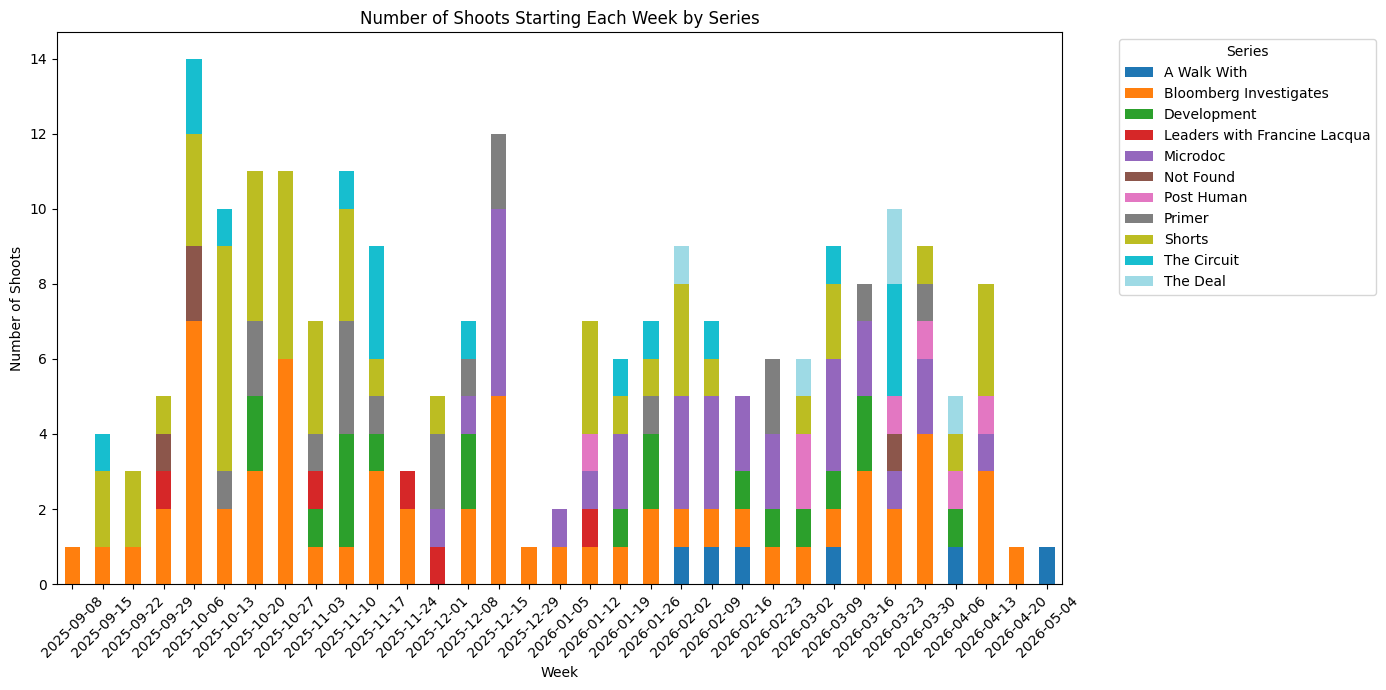

In [ ]:
# Group by both 'week' and 'Series', then unstack to get a table suitable for plotting
weekly_series_counts = (
    clean_df.groupby(["week", "Series"]).size().unstack(fill_value=0)
)

plt.figure(figsize=(14, 7))
weekly_series_counts.plot(kind="bar", stacked=True, colormap="tab20", ax=plt.gca())
plt.xlabel("Week")
plt.ylabel("Number of Shoots")
plt.title("Number of Shoots Starting Each Week by Series")
plt.xticks(
    ticks=range(len(weekly_series_counts.index)),
    labels=[d.strftime("%Y-%m-%d") for d in weekly_series_counts.index],
    rotation=45,
)
plt.legend(title="Series", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [ ]:
weekly_series_counts.head()

Series,A Walk With,Bloomberg Investigates,Development,Leaders with Francine Lacqua,Microdoc,Not Found,Post Human,Primer,Shorts,The Circuit,The Deal
week,,,,,,,,,,,
2025-09-08,0,1,0,0,0,0,0,0,0,0,0
2025-09-15,0,1,0,0,0,0,0,0,2,1,0
2025-09-22,0,1,0,0,0,0,0,0,2,0,0
2025-09-29,0,2,0,1,0,1,0,0,1,0,0
2025-10-06,0,7,0,0,0,2,0,0,3,2,0


In [ ]:
weekly_series_counts.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 33 entries, 2025-09-08 to 2026-05-04
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   A Walk With                   33 non-null     int64
 1   Bloomberg Investigates        33 non-null     int64
 2   Development                   33 non-null     int64
 3   Leaders with Francine Lacqua  33 non-null     int64
 4   Microdoc                      33 non-null     int64
 5   Not Found                     33 non-null     int64
 6   Post Human                    33 non-null     int64
 7   Primer                        33 non-null     int64
 8   Shorts                        33 non-null     int64
 9   The Circuit                   33 non-null     int64
 10  The Deal                      33 non-null     int64
dtypes: int64(11)
memory usage: 3.1 KB


In [ ]:
weekly_series_counts.describe()

Series,A Walk With,Bloomberg Investigates,Development,Leaders with Francine Lacqua,Microdoc,Not Found,Post Human,Primer,Shorts,The Circuit,The Deal
count,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000
mean,0.181818,1.878788,0.575758,0.151515,0.909091,0.121212,0.212121,0.545455,1.454545,0.484848,0.151515
std,0.391675,1.634732,0.830298,0.364110,1.259058,0.415149,0.484612,0.832575,1.602555,0.833712,0.441674
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,2.000000,1.000000,0.000000,2.000000,0.000000,0.000000,1.000000,3.000000,1.000000,0.000000
max,1.000000,7.000000,3.000000,1.000000,5.000000,2.000000,2.000000,3.000000,6.000000,3.000000,2.000000


In [ ]:
not_found_series = clean_df[clean_df["Series"] == "Not Found"]
not_found_series

,Status,Series,Episode,Shoot Location,Shoot Dates,Who is Prepping,Days between Footage Rcvd and Prep Needed,Prep Priority,When Will Footage Be Received by Post,Date Footage Actually Received,When Is Prep Needed By,Date Prep Completed,Days it took to Prep,Shoot Start Date,Total Number of Shoot Days,Shoot End Date,AE Requests,"If Translations Are Needed, What Language",Is this currently in edit?,Dropped / Shipped / Uploaded,Where is footage being delivered to?,How is it being delivered?,How is Media Being Returned,Showrunner / Lead Producer,Equipment,Shoot ID,Timestamp,Vertical,Cross Platform Videos,Time Between Submission and Shoot Start,week
11,Complete,Not Found,Plot episode,London,03-Oct-2025,NaN,<NA>,#REF!,2025-10-02,2025-10-03,NaT,NaT,<NA>,2025-10-03,1,2025-10-03,"Stringouts, Transcripts",NaN,No,Uploaded to Frame.io,NaN,NaN,Remote (Frame.io Upload),NaN,NaN,NaN,2025-10-01 09:03:26,NaN,NaN,2,2025-09-29
13,Complete,Not Found,Emmanuel Acho,Los Angeles,06-Oct-2025,NaN,2,#REF!,2025-10-07,2025-10-07,2025-10-09,2025-10-09,<NA>,2025-10-06,1,2025-10-06,"Stringouts, Transcripts",NaN,No,Dropped at NYC Office - 731 Lexington Ave,NYC Office - 731 Lexington Ave,Drives Dropped off at Office,Drives or Cards,NaN,NaN,NaN,2025-09-26 13:39:36,NaN,NaN,10,2025-10-06
15,Complete,Not Found,OS_BBN_china_mega_dam,"UC Santa Barbara, California",07-Oct-2025,NaN,4,#REF!,2025-10-09,2025-10-09,2025-10-13,2025-10-13,<NA>,2025-10-07,1,2025-10-07,"Stringouts, Transcripts",NaN,No,Dropped at NYC Office - 731 Lexington Ave,NYC Office - 731 Lexington Ave,Drives Dropped off at Office,Drives or Cards,NaN,NaN,NaN,2025-09-29 18:00:00,NaN,NaN,8,2025-10-06
162,Done by Editor,Not Found,NaN,QVS Studio D,25-Mar-2026,Editor,0,Urgent,2026-03-25,2026-03-25,2026-03-25,2026-03-25,1,2026-03-25,1,2026-03-25,Stringouts,NaN,No,Dropped at London Office - 3 Queen Victoria St...,"London Office - 3 Queen Victoria St, London",Cards Dropped off at Office,Drives or Cards,Atalandi Dixon,Bloomberg London Equipment,NaN,2026-03-23 13:38:27,Long Form,NaN,2,2026-03-23


In [ ]:
# TODO: put the "Not Found" cleaning into the clean_data function.